# Perceptron for OCR - MNIST Digit Recognition

This notebook implements a Convolutional Neural Network (CNN) for recognizing handwritten digits from the MNIST dataset using PyTorch and PyTorch Lightning. It's a refactored version of a separate implementation, designed to be more interactive.

## About the MNIST Dataset
The MNIST (Modified National Institute of Standards and Technology) dataset consists of 70,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9. The dataset is divided into 60,000 training images and 10,000 testing images.

## What We'll Accomplish
In this notebook, we will:
1. Load and preprocess the MNIST dataset with data augmentation
2. Build a convolutional neural network using PyTorch Lightning
3. Train the model with proper validation and checkpointing
4. Evaluate the model's performance
5. Visualize predictions and test interactively

The model architecture uses convolutional layers, batch normalization, and dropout for regularization to achieve high accuracy (>99% on the test set).

## Key Features
- Data augmentation for improved model robustness
- Convolutional neural network architecture
- Batch normalization and dropout for regularization
- Learning rate scheduling
- Model checkpointing and monitoring with Weights & Biases (WandB)
- Test evaluation and interactive visualization

## Imports and Setup

Before we begin building our model, we need to import the necessary libraries and set up our environment. The following cell installs any required packages if they're not already installed.

In [ ]:
# Remember to install the required packages before running the notebook.
# I have been using python version 3.12.1 during development.
!pip install -r requirements.txt

Now let's import all the modules we'll need throughout this notebook:

In [1]:
import os
import time
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint
import wandb
from torchmetrics import Accuracy
import matplotlib.pyplot as plt
from IPython.display import display

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Enable tensor core optimization for NVIDIA GPUs if available
if device == "cuda":
    torch.set_float32_matmul_precision("high")
    
# Create directories for saving model checkpoints
os.makedirs("checkpoints", exist_ok=True)

Using device: cuda


The code above accomplishes several things:
1. Imports necessary libraries for deep learning (PyTorch, PyTorch Lightning)
2. Imports utilities for data manipulation and visualization
3. Sets random seeds for reproducibility across runs
4. Checks for GPU availability and enables optimizations if available
5. Creates a directory to store model checkpoints

## Hyperparameter Configuration

One of the key goals of this notebook is to make hyperparameter tuning more intuitive and accessible. In this section, we define all the hyperparameters that will be used throughout the notebook. This makes it easy to experiment with different configurations.

The hyperparameters are organized into different categories:
- Model architecture parameters: These define the structure of the neural network
- Training parameters: These control the training process
- Data parameters: These define how the data is processed and split

In [2]:
# MODEL ARCHITECTURE PARAMETERS
INPUT_SIZE = 784              # Size of flattened MNIST images (28x28)
HIDDEN_SIZE = 128             # Size of hidden layer (legacy parameter, kept for compatibility)
OUTPUT_SIZE = 10              # Number of output classes (digits 0-9)
CONV_CHANNELS1 = 64           # Number of filters in first conv layer
CONV_CHANNELS2 = 128          # Number of filters in second conv layer
CONV_CHANNELS3 = 256          # Number of filters in third conv layer
KERNEL_SIZE = 3               # Size of convolutional kernels
FC_SIZE = 128                 # Size of fully connected layer after convolutions

# TRAINING PARAMETERS
LEARNING_RATE = 1e-3          # Initial learning rate
WEIGHT_DECAY = 5e-6           # L2 regularization term
DROPOUT_RATE = 0.3            # Dropout probability for regularization
MAX_EPOCHS = 40               # Maximum number of training epochs
BATCH_SIZE = 64               # Batch size for training
VAL_BATCH_SIZE = BATCH_SIZE*2 # Larger batch size for validation (more efficient)

# DATA PARAMETERS
VAL_SPLIT = 0.1667            # Portion of training data to use for validation (~10k out of 60k)

# PATHS AND OTHER SETTINGS
CHECKPOINTS_DIR = "checkpoints"    # Directory to save model checkpoints
WANDB_PROJECT = "pytorch-mnist-ocr" # WandB project name

This clear organization of hyperparameters makes it easy to:
1. Understand which parameters control different aspects of the model
2. Experiment with different configurations
3. Document the optimal values found through experimentation

The values chosen here represent a configuration that has been proven to achieve high accuracy (>99%) on the MNIST dataset.

## Data Loading Functions

In this section, we define the functions needed to load, preprocess, and augment the MNIST dataset. Data augmentation is a crucial technique for improving model generalization by creating variations of the training data.

First, we'll create a custom Dataset wrapper that applies transformations to a subset of another dataset:

In [4]:
class TransformedSubset(Dataset):
    """Dataset wrapper that applies a transform to a subset of another dataset."""

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

Now we'll implement the main function for loading and preparing the MNIST data:

In [5]:
def get_dataloaders(batch_size=BATCH_SIZE, val_batch_size=VAL_BATCH_SIZE, val_split=VAL_SPLIT):
    """
    Gets and splits the MNIST training data into training and validation DataLoaders.
    
    Args:
        batch_size: Batch size for training
        val_batch_size: Batch size for validation
        val_split: Portion of training data to use for validation
        
    Returns:
        Tuple of (train_loader, val_loader)
    """
    # Define the base transform that converts PIL images to tensors (no normalization yet)
    base_transform = transforms.ToTensor()

    # Load the full training dataset with just the base transform
    full_dataset = datasets.MNIST(
        root="./data/MNIST",
        train=True,
        download=True,
        transform=base_transform,
    )

    # Calculate split sizes
    total_size = len(full_dataset)
    val_size = int(total_size * val_split)
    train_size = total_size - val_size

    # Split the dataset
    generator = torch.Generator().manual_seed(42)  # For reproducibility
    train_subset, val_subset = random_split(
        full_dataset, [train_size, val_size], generator=generator
    )

    # Define the augmentation transforms for training data
    train_transform = transforms.Compose(
        [
            # These transforms expect tensor input (since we already called ToTensor)
            transforms.RandomAffine(
                degrees=10, translate=(0.1, 0.1), scale=(0.85, 1.05)
            ),
            transforms.ElasticTransform(alpha=50.0, sigma=5.0),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            # Normalize at the end
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )

    # Define transform for validation data (just normalization)
    val_transform = transforms.Normalize((0.5,), (0.5,))

    # Create wrapped datasets with appropriate transforms
    train_dataset = TransformedSubset(train_subset, train_transform)
    val_dataset = TransformedSubset(val_subset, val_transform)

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    print(
        f"Dataset split: {train_size} training samples (with augmentation), "
        f"{val_size} validation samples (no augmentation)."
    )
    return train_loader, val_loader

We'll also add a function to load the test dataset for final evaluation:

In [3]:
def load_test_dataset(batch_size=100):
    """
    Load the MNIST test dataset using torchvision.
    
    Args:
        batch_size: The batch size for the DataLoader
        
    Returns:
        DataLoader: A DataLoader for the MNIST test dataset
    """
    # Define normalization transform to match our training (-0.5, 0.5)
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )

    # Load the test dataset
    test_dataset = datasets.MNIST(
        root="./data/MNIST", train=False, download=True, transform=transform
    )

    # Create DataLoader
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    
    print(f"Test dataset: {len(test_dataset)} samples")
    return test_loader

Finally, we'll add a utility function to load a single digit image for testing:

In [7]:
def get_digit_image(n):
    """
    Get a test image of a specific digit.
    
    Args:
        n: The digit (0-9) to retrieve
        
    Returns:
        Tuple of (tensor_image, original_image):
            - tensor_image: Normalized PyTorch tensor for model input
            - original_image: Raw image data for display
    """
    # Load test dataset without normalization for display
    dataset_display = datasets.MNIST(
        root="./data/MNIST", train=False, download=True, transform=transforms.ToTensor()
    )
    
    # Load test dataset with normalization for model input
    dataset_model = datasets.MNIST(
        root="./data/MNIST", 
        train=False, 
        download=True, 
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    )
    
    # Find images of the requested digit
    digit_indices = [i for i, (_, label) in enumerate(dataset_display) if label == n]
    
    if not digit_indices:
        raise ValueError(f"No images found with label {n}")
    
    # Choose a random image of the digit
    idx = np.random.choice(digit_indices)
    
    # Get both the display and model versions
    display_image, _ = dataset_display[idx]
    model_image, _ = dataset_model[idx]
    
    return model_image, display_image

These functions handle all aspects of data loading, augmentation, and preprocessing, following best practices for training deep learning models.


Before training our model, it's important to visualize the dataset to understand the data we're working with. In this section, we'll create visualizations of the MNIST digits and demonstrate the effect of our data augmentation pipeline.

First, let's load and visualize a batch of images from the dataset:

In [ ]:
def visualize_mnist_samples(num_samples=10):
    """
    Display a grid of random MNIST digits.
    
    Args:
        num_samples: Number of samples to display
    """
    # Load the MNIST dataset
    dataset = datasets.MNIST(
        root="./data/MNIST", train=True, download=True, transform=transforms.ToTensor()
    )
    
    # Set up the figure
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples*1.5, 2))
    
    # Get random indexes
    indices = torch.randperm(len(dataset))[:num_samples]
    
    # Display each image
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        axes[i].set_title(f"Digit: {label}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display 10 random digits from the MNIST dataset
visualize_mnist_samples(10)

Next, let's visualize the effect of our data augmentation pipeline by showing the original image and multiple augmented versions:

In [ ]:
def visualize_augmentations(digit=None, num_augmentations=5):
    """
    Visualize the effect of data augmentation on MNIST digits.
    
    Args:
        digit: Specific digit to visualize, or None for random
        num_augmentations: Number of augmented versions to display
    """
    # Load the dataset
    dataset = datasets.MNIST(
        root="./data/MNIST", train=True, download=True, transform=transforms.ToTensor()
    )
    
    # Find a specific digit if requested
    if digit is not None:
        indices = [i for i, (_, label) in enumerate(dataset) if label == digit]
        if not indices:
            raise ValueError(f"No images found with label {digit}")
        idx = np.random.choice(indices)
    else:
        idx = np.random.randint(0, len(dataset))
    
    original_img, label = dataset[idx]
    
    # Define the augmentation transforms (same as in our training pipeline)
    augmentation = transforms.Compose([
        transforms.RandomAffine(
            degrees=10, translate=(0.1, 0.1), scale=(0.85, 1.05)
        ),
        transforms.ElasticTransform(alpha=50.0, sigma=5.0),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
    ])
    
    # Set up the figure
    fig, axes = plt.subplots(1, num_augmentations + 1, figsize=((num_augmentations + 1) * 1.5, 2))
    
    # Display original image
    axes[0].imshow(original_img.squeeze().numpy(), cmap='gray')
    axes[0].set_title(f"Original: {label}")
    axes[0].axis('off')
    
    # Generate and display augmented images
    for i in range(num_augmentations):
        # Apply augmentations
        augmented_img = augmentation(original_img)
        
        # Display augmented image
        axes[i+1].imshow(augmented_img.squeeze().numpy(), cmap='gray')
        axes[i+1].set_title(f"Augmented {i+1}")
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return f"Showing augmentations for digit {label}"

# Visualize augmentations for a random digit
print(visualize_augmentations())

# Visualize augmentations for each digit 0-9
for digit in range(10):
    print(visualize_augmentations(digit=digit))

This visualization demonstrates how data augmentation creates variations of the training data, which helps the model generalize better to unseen examples. The transformations include:

1. **Random Affine**: Applies random rotations, translations, and scaling
2. **Elastic Transform**: Applies elastic deformations to simulate natural variations in handwriting
3. **Color Jitter**: Varies brightness and contrast

These augmentations help the model become more robust to variations in the input data, reducing overfitting and improving generalization to real-world examples.

## Neural Network Model Definition

Now we'll define our neural network model using PyTorch Lightning. This model is a convolutional neural network (CNN) that uses convolutional layers to automatically learn spatial hierarchies of features from the input images. This architecture is particularly well-suited for image classification tasks.

We'll implement the model as a PyTorch Lightning module, which provides a structured way to organize our code and makes it easy to train and evaluate the model.

In [4]:
class MNISTClassifier(pl.LightningModule):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        output_size=OUTPUT_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        dropout_rate=DROPOUT_RATE,
        conv_channels1=CONV_CHANNELS1,
        conv_channels2=CONV_CHANNELS2,
        conv_channels3=CONV_CHANNELS3,
        kernel_size=KERNEL_SIZE,
        fc_size=FC_SIZE,
    ):
        """
        Initialize a convolutional neural network for image classification.

        Args:
            input_size: Size of the input (784 for MNIST flattened images)
            hidden_size: Size of the hidden layer (kept for compatibility)
            output_size: Size of the output layer (10 for digits 0-9)
            learning_rate: Learning rate for the optimizer
            weight_decay: L2 regularization term
            dropout_rate: Dropout probability for regularization
            conv_channels1: Number of filters in first convolutional layer
            conv_channels2: Number of filters in second convolutional layer
            conv_channels3: Number of filters in third convolutional layer
            kernel_size: Size of the convolutional kernel
            fc_size: Size of the fully connected layer after convolutions
        """
        super().__init__()

        # Save hyperparameters for easy access later
        self.save_hyperparameters()

        # Define the convolutional layers
        # First conv layer: 1 input channel (grayscale) -> conv_channels1 output channels
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=conv_channels1,
            kernel_size=kernel_size,
            padding=1,
        )
        # Batch normalization after first conv layer
        self.bn1 = nn.BatchNorm2d(conv_channels1)
        # MaxPooling layer to reduce spatial dimensions
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second conv layer: conv_channels1 input channels -> conv_channels2 output channels
        self.conv2 = nn.Conv2d(
            in_channels=conv_channels1,
            out_channels=conv_channels2,
            kernel_size=kernel_size,
            padding=1,
        )
        # Batch normalization after second conv layer
        self.bn2 = nn.BatchNorm2d(conv_channels2)

        # Third conv layer: conv_channels2 input channels -> conv_channels3 output channels
        self.conv3 = nn.Conv2d(
            in_channels=conv_channels2,
            out_channels=conv_channels3,
            kernel_size=kernel_size,
            padding=1,
        )
        # Batch normalization after third conv layer
        self.bn3 = nn.BatchNorm2d(conv_channels3)

        # Calculate the size of the flattened features after convolutions and pooling
        # 28x28 -> after first conv+pool -> 14x14 -> after second conv+pool -> 7x7 -> after third conv+pool -> 3x3
        # So the flattened size will be 3*3*conv_channels3
        self.flat_size = 3 * 3 * conv_channels3

        # Fully connected layers
        self.fc1 = nn.Linear(self.flat_size, fc_size)
        self.fc2 = nn.Linear(fc_size, output_size)

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Define loss function
        self.criterion = nn.CrossEntropyLoss()

        # Define metric for accuracy calculation
        self.accuracy = Accuracy(task="multiclass", num_classes=output_size)

        # Initialize weights
        self._initialize_weights()

    @property
    def conv_layers(self):
        """Creates a list structure for conv layers"""
        return [[self.conv1], [self.conv2], [self.conv3]]
    
    @property
    def fc_layers(self):
        """Creates a list structure for fc layers"""
        return [[self.fc1], [self.fc2]]

    def _initialize_weights(self):
        """Initialize weights using He-initialization"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor that can be in multiple formats:
            - Shape (784,) for a single flattened image
            - Shape (batch_size, 784) for batched flattened images
            - Shape (batch_size, 1, 28, 28) for batched MNIST images

        Returns:
            Output tensor of shape (batch_size, output_size)
        """
        # Ensure input has the right shape
        if x.dim() == 1:
            # Single flattened image, reshape to [1, 1, 28, 28]
            x = x.view(1, 1, 28, 28)
        elif x.dim() == 2:
            # Batch of flattened images, reshape to [batch_size, 1, 28, 28]
            batch_size = x.size(0)
            x = x.view(batch_size, 1, 28, 28)
        elif x.dim() == 4 and x.size(1) == 1:
            # Already in the correct format [batch_size, 1, 28, 28]
            pass
        else:
            raise ValueError(f"Unexpected input tensor shape: {x.shape}")

        # First convolutional layer: Conv2d -> BatchNorm -> ReLU -> MaxPool
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Second convolutional layer: Conv2d -> BatchNorm -> ReLU -> MaxPool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Third convolutional layer: Conv2d -> BatchNorm -> ReLU -> MaxPool
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)

        # Flatten the output for the fully connected layers
        x = x.view(x.size(0), -1)

        # First fully connected layer with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Output layer
        x = self.fc2(x)

        return x

    def training_step(self, batch, batch_idx):
        """Defines the training loop logic for a single batch."""
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, targets)

        # Log loss and accuracy
        self.log(
            "train_loss",
            loss,
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )
        acc = self.accuracy(outputs, targets)
        self.log(
            "train_acc",
            acc,
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )

        return loss

    def validation_step(self, batch, batch_idx):
        """Defines the validation loop logic for a single batch."""
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, targets)
        acc = self.accuracy(outputs, targets)

        # Log validation loss and accuracy
        # Important: Use on_epoch=True so the average over the epoch is logged
        # prog_bar=True displays it in the progress bar
        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )
        self.log(
            "val_acc",
            acc,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )

        return loss

    def configure_optimizers(self):
        """Configures the optimizer and learning rate scheduler."""
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay,
        )

        # Learning rate scheduler that reduces LR when validation accuracy plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",  # We are monitoring accuracy (if monitoring loss, choose 'min').
            factor=0.5,  # When scheduler is triggered, LR is reduced by 50%
            patience=3,  # Waits 3 epochs after reducing LR
            verbose=True,  # Print message when LR is reduced
            min_lr=1e-6,  # Floor of LR
            threshold=0.0001,  # Minimum change to qualify as an improvement (0.01%)
            threshold_mode="rel",  # Interpret threshold as relative change
        )

        # Return both optimizer and scheduler in the format PyTorch Lightning expects
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_acc",  # The metric to monitor for plateau detection
                "interval": "epoch",  # The scheduler updates after each epoch
                "frequency": 1,  # Update the scheduler every epoch
                "strict": False,  # Don't crash if the monitored metric is missing
            },
        }

    def predict(self, vector):
        """
        Process a flattened image through the network.

        Args:
            vector: A 1D tensor of shape (784,) or a batch tensor

        Returns:
            A list of 10 probabilities corresponding to digits 0-9 (for single vector input)
            or a tensor of probabilities (for batch input)
        """
        self.eval()

        if not isinstance(vector, torch.Tensor):
            raise ValueError("Input must be a torch.Tensor")

        is_single_vector = False
        if vector.dim() == 1 and vector.shape[0] == 784:
            vector = vector.unsqueeze(0)
            is_single_vector = True
        elif vector.dim() == 2 and vector.shape[1] == 784:
            pass
        elif (
            vector.dim() == 4
            and vector.size(1) == 1
            and vector.size(2) == 28
            and vector.size(3) == 28
        ):
            pass
        else:
            raise ValueError(
                f"Expected input of size (784,) or (batch, 784) or (batch, 1, 28, 28), got {vector.shape}"
            )

        with torch.no_grad():
            logits = self.forward(vector)
            predictions = F.softmax(logits, dim=1)

        if is_single_vector:
            return predictions.squeeze().tolist()
        else:
            return predictions

    @staticmethod
    def load_from_checkpoint_custom(checkpoint_path, device="cpu"):
        """
        Loads a model from a PyTorch Lightning checkpoint.
        Moves model to the correct device.
        Sets model to eval mode.

        Args:
            checkpoint_path (str): Path to the checkpoint file (.ckpt).
            device (str): Device to load the model onto ('cpu' or 'cuda').

        Returns:
            MNISTClassifier: The loaded model instance.
        """
        model = MNISTClassifier.load_from_checkpoint(
            checkpoint_path, map_location=device
        )
        model.eval()
        print(
            f"Lightning Checkpoint loaded from {checkpoint_path} to {device}"
        )
        return model

The model architecture can be summarized as follows:

1. **Convolutional Layers:**
   - Three convolutional layers with increasing filter counts (64, 128, 256)
   - Batch normalization after each convolutional layer for faster and more stable training
   - ReLU activation functions to introduce non-linearity
   - Max pooling to reduce spatial dimensions and increase the field of view

2. **Fully Connected Layers:**
   - After flattening the output of the convolutional layers, we have two fully connected layers
   - Dropout between fully connected layers to prevent overfitting
   - Final layer outputs logits for each of the 10 possible digits

3. **PyTorch Lightning Integration:**
   - Organized training and validation steps
   - Learning rate scheduling based on validation accuracy
   - Metrics tracking for monitoring training progress

This architecture provides a good balance between complexity and performance, allowing the model to learn useful representations of the handwritten digits while avoiding overfitting.

## Training Configuration and Setup

Now we'll set up the training process using PyTorch Lightning with Weights & Biases (WandB) integration for experiment tracking. This configuration will handle model checkpointing, logging, and other aspects of the training process.

First, let's define a function to handle checkpoint management:

In [5]:
def find_latest_checkpoint(checkpoint_dir=CHECKPOINTS_DIR):
    """
    Find the latest checkpoint file in the specified directory.
    
    Args:
        checkpoint_dir: Directory to search for checkpoint files
        
    Returns:
        Path to the latest checkpoint file, or None if no checkpoint is found
    """
    if not os.path.exists(checkpoint_dir):
        return None
    
    # Get all checkpoint files
    checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "*.ckpt"))
    
    if not checkpoint_files:
        return None
    
    # Sort by modification time (newest first)
    checkpoint_files.sort(key=os.path.getmtime, reverse=True)
    
    checkpoint = checkpoint_files[0]
    print(f"Found checkpoint: {checkpoint}")
    
    return checkpoint

Now, let's set up the training configuration with WandB and ModelCheckpoint:

In [6]:
def setup_training(model, max_epochs=MAX_EPOCHS):
    """
    Set up PyTorch Lightning training with WandB logging and model checkpointing.
    
    Args:
        model: PyTorch Lightning model (MNISTClassifier instance)
        max_epochs: Maximum number of training epochs
        
    Returns:
        PyTorch Lightning Trainer configured with loggers and callbacks
    """
    # Initialize WandB logger
    wandb_logger = WandbLogger(project=WANDB_PROJECT, log_model=True)
    
    # Monitor the model
    wandb_logger.watch(model, log="all")
    
    # Wait a moment for the run to be properly initialized
    time.sleep(1)
    
    # Get the run name from WandB so we can save it accordingly
    run_name = wandb.run.name
    print(f"WandB run name: {run_name}")
    
    # Configure checkpoint callback to save the best model
    checkpoint_callback = ModelCheckpoint(
        dirpath=CHECKPOINTS_DIR,
        filename=f"{run_name}-{{epoch}}-{{val_acc:.4f}}",
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        verbose=True,
    )
    
    # Configure hardware acceleration
    accelerator = "gpu" if torch.cuda.is_available() else "cpu"
    print(f"Training on {accelerator.upper()}")
    
    # Set up the trainer
    trainer = pl.Trainer(
        logger=wandb_logger,
        callbacks=[checkpoint_callback],
        max_epochs=max_epochs,
        accelerator=accelerator,
        devices=1 if accelerator != "cpu" else None,
        log_every_n_steps=50,
        deterministic=True,  # For reproducibility
    )
    
    return trainer

These functions provide a clean way to:

1. Set up the WandB logger for experiment tracking
2. Configure model checkpointing to save the best model based on validation accuracy
3. Set up hardware acceleration (GPU if available)
4. Create a PyTorch Lightning Trainer with all the necessary components

WandB integration is particularly useful for:
- Tracking metrics like loss and accuracy across training epochs
- Comparing different model configurations
- Visualizing training progress
- Organizing and documenting experiments

The ModelCheckpoint callback ensures that we save the model with the best validation accuracy, which is crucial for getting the best performance on unseen data.

## Training Execution

Now that we have defined our model and set up the training configuration, we can execute the training process. We'll define a function that ties everything together and then run it.

In [7]:
def train_model(max_epochs=MAX_EPOCHS):
    """
    Train the MNIST classifier model from scratch.
    
    Args:
        max_epochs: Maximum number of epochs to train for
        
    Returns:
        Tuple of (trained_model, best_checkpoint_path)
    """
    print("Starting model training...")
    
    # Create dataloaders for training and validation
    train_loader, val_loader = get_dataloaders()
    
    # Initialize the model
    model = MNISTClassifier()
    
    # Setup training (WandB, checkpointing, etc.)
    trainer = setup_training(model, max_epochs=max_epochs)
    
    # Start training
    print(f"Training for {max_epochs} epochs...")
    trainer.fit(
        model=model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader,
    )
    
    # After training, find the latest checkpoint
    best_checkpoint_path = find_latest_checkpoint()
    
    # Finish WandB run
    wandb.finish()
    
    print(f"Training complete! Best model saved to: {best_checkpoint_path}")
    return model, best_checkpoint_path

Let's also define a function for loading a pre-trained model from a checkpoint:

In [8]:
def load_model_from_checkpoint(checkpoint_path=None):
    """
    Load a model from a checkpoint or train a new one if no checkpoint exists.
    
    Args:
        checkpoint_path: Path to checkpoint file, if None will search for one
        
    Returns:
        The loaded model
    """
    if checkpoint_path is None:
        checkpoint_path = find_latest_checkpoint()
    
    if checkpoint_path:
        print(f"Loading model from checkpoint: {checkpoint_path}")
        model = MNISTClassifier.load_from_checkpoint_custom(
            checkpoint_path, device=device
        )
        return model
    else:
        print("No checkpoint found. Training a new model...")
        model, _ = train_model()
        return model

Now let's execute the training (or load from a checkpoint if available):

In [9]:
# Try to load a model from checkpoint, or train a new one if not available
model = load_model_from_checkpoint()

# If you want to force training a new model, uncomment the line below
# model, checkpoint_path = train_model(max_epochs=MAX_EPOCHS)

print("Model ready for evaluation and testing!")

Found checkpoint: checkpoints\genial-night-29-epoch=38-val_acc=0.9962.ckpt
Loading model from checkpoint: checkpoints\genial-night-29-epoch=38-val_acc=0.9962.ckpt
Lightning Checkpoint loaded from checkpoints\genial-night-29-epoch=38-val_acc=0.9962.ckpt to cuda
Model ready for evaluation and testing!


During training, PyTorch Lightning will display a progress bar with metrics such as training loss, training accuracy, and validation accuracy. These metrics are also logged to WandB, where you can view detailed charts and visualizations of the training process.

The training process typically takes about 60 minutes on a modern GPU, and should achieve validation accuracy of around 99% or higher.

### Understanding the Training Output

When running the training, you'll see output similar to this:
```
Dataset split: 50000 training samples (with augmentation), 10000 validation samples (no augmentation).
WandB run name: dazzling-violet-2
Training on GPU
Epoch 1/40: 100%|█████████████| 782/782 [00:42<00:00, 18.62it/s, loss=0.0428, acc=0.987, val_loss=0.0348, val_acc=0.989]
Epoch 2/40: 100%|█████████████| 782/782 [00:40<00:00, 19.25it/s, loss=0.0201, acc=0.993, val_loss=0.0298, val_acc=0.991]
...
```

This output shows:
- Progress through each epoch
- Training loss and accuracy
- Validation loss and accuracy
- Speed of training (iterations per second)

The ModelCheckpoint callback saves the model whenever the validation accuracy improves. At the end of training, we load the best checkpoint, which corresponds to the model with the highest validation accuracy across all epochs.s

## Checkpoint Management Functions

We've already defined basic checkpoint management in our training setup, but let's create some additional utility functions to make it easier to work with checkpoints. These functions will help us find, load, and manage model checkpoints more effectively.

In [10]:
def list_all_checkpoints(checkpoint_dir=CHECKPOINTS_DIR):
    """
    List all available checkpoints in the specified directory.
    
    Args:
        checkpoint_dir: Directory to search for checkpoint files
        
    Returns:
        List of checkpoint file paths sorted by modification time (newest first)
    """
    if not os.path.exists(checkpoint_dir):
        print(f"Checkpoint directory '{checkpoint_dir}' does not exist.")
        return []
    
    # Get all checkpoint files
    checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "*.ckpt"))
    
    if not checkpoint_files:
        print(f"No checkpoint files found in '{checkpoint_dir}'.")
        return []
    
    # Sort by modification time (newest first)
    checkpoint_files.sort(key=os.path.getmtime, reverse=True)
    
    # Print the checkpoints with their metadata
    print(f"Found {len(checkpoint_files)} checkpoint(s):")
    for i, checkpoint in enumerate(checkpoint_files):
        # Extract metadata from the filename
        filename = os.path.basename(checkpoint)
        
        # Try to parse epoch and accuracy from filename (format: [runname]-[epoch]-[val_acc].ckpt)
        try:
            # Extract information from the filename parts
            parts = filename.replace('.ckpt', '').split('-')
            if len(parts) >= 3:
                # Run name could contain hyphens, so join all but the last two parts
                run_name = '-'.join(parts[:-2])
                epoch = parts[-2]
                accuracy = parts[-1]
                
                # Format the output
                print(f"  {i+1}. {filename}")
                print(f"     Run: {run_name}, Epoch: {epoch}, Accuracy: {accuracy}")
                print(f"     Last Modified: {time.ctime(os.path.getmtime(checkpoint))}")
            else:
                # If filename doesn't match expected format
                print(f"  {i+1}. {filename}")
                print(f"     Last Modified: {time.ctime(os.path.getmtime(checkpoint))}")
        except Exception as e:
            # If there's any error in parsing
            print(f"  {i+1}. {filename}")
            print(f"     Last Modified: {time.ctime(os.path.getmtime(checkpoint))}")
    
    return checkpoint_files


def compare_checkpoints(checkpoint_paths, test_loader=None):
    """
    Compare the performance of multiple checkpoints on the test dataset.
    
    Args:
        checkpoint_paths: List of checkpoint file paths to compare
        test_loader: DataLoader for the test dataset, created if None
        
    Returns:
        Dictionary mapping checkpoint paths to their test accuracy
    """
    if not checkpoint_paths:
        print("No checkpoints to compare.")
        return {}
    
    # Create test loader if not provided
    if test_loader is None:
        test_loader = load_test_dataset()
    
    results = {}
    
    # Loop through each checkpoint
    for checkpoint_path in checkpoint_paths:
        try:
            # Load the model
            model = MNISTClassifier.load_from_checkpoint_custom(checkpoint_path, device=device)
            model.eval()
            
            # Calculate accuracy on test set
            correct = 0
            total = 0
            
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            
            accuracy = 100 * correct / total
            results[checkpoint_path] = accuracy
            
            # Print result
            print(f"Checkpoint: {os.path.basename(checkpoint_path)}")
            print(f"Test Accuracy: {accuracy:.4f}%")
            print("-" * 50)
        
        except Exception as e:
            print(f"Error evaluating checkpoint {checkpoint_path}: {e}")
            results[checkpoint_path] = float('nan')
    
    # Sort and find the best checkpoint
    if results:
        best_checkpoint = max(results.items(), key=lambda x: x[1])
        print(f"\nBest checkpoint: {os.path.basename(best_checkpoint[0])}")
        print(f"Test Accuracy: {best_checkpoint[1]:.4f}%")
    
    return results

Let's test these functions by listing all available checkpoints:

Found 4 checkpoint(s):
  1. genial-night-29-epoch=38-val_acc=0.9962.ckpt
     Run: genial-night-29, Epoch: epoch=38, Accuracy: val_acc=0.9962
     Last Modified: Tue May  6 11:00:45 2025
  2. blooming-wood-28-epoch=38-val_acc=0.9963.ckpt
     Run: blooming-wood-28, Epoch: epoch=38, Accuracy: val_acc=0.9963
     Last Modified: Tue May  6 08:59:29 2025
  3. dark-nexu-27-epoch=38-val_acc=0.9966.ckpt
     Run: dark-nexu-27, Epoch: epoch=38, Accuracy: val_acc=0.9966
     Last Modified: Mon May  5 19:11:49 2025
  4. holographic-admiral-26-epoch=39-val_acc=0.9970.ckpt
     Run: holographic-admiral-26, Epoch: epoch=39, Accuracy: val_acc=0.9970
     Last Modified: Mon May  5 15:36:01 2025
Test dataset: 10000 samples
Lightning Checkpoint loaded from checkpoints\genial-night-29-epoch=38-val_acc=0.9962.ckpt to cuda
Checkpoint: genial-night-29-epoch=38-val_acc=0.9962.ckpt
Test Accuracy: 99.6300%
--------------------------------------------------
Lightning Checkpoint loaded from checkpoints\blooming

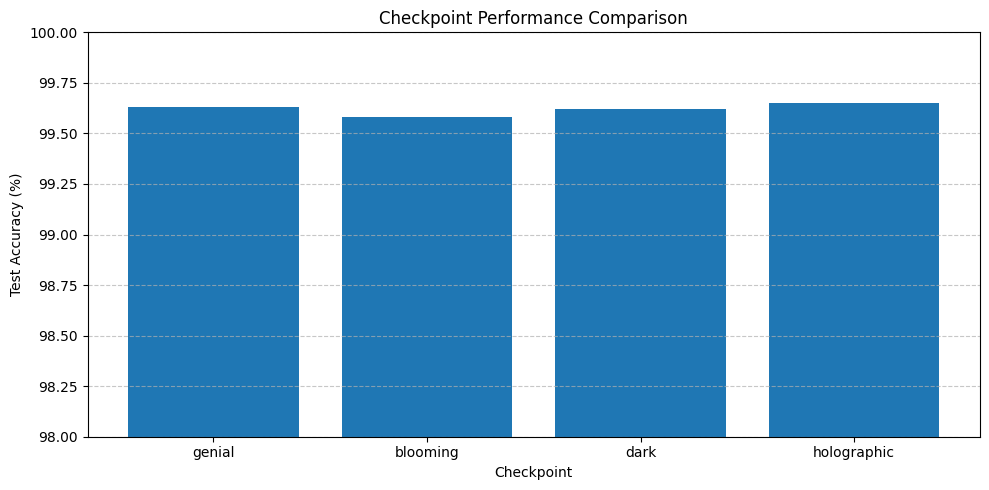

In [11]:
# List all available checkpoints
checkpoint_files = list_all_checkpoints()

# If we have multiple checkpoints, we can compare their performance
if len(checkpoint_files) > 1:
    results = compare_checkpoints(checkpoint_files[:5])  # Compare top 5 checkpoints
    
    # Visualize the comparison
    plt.figure(figsize=(10, 5))
    plt.bar(
        [os.path.basename(cp).split('-')[0] for cp in results.keys()], 
        list(results.values())
    )
    plt.xlabel('Checkpoint')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Checkpoint Performance Comparison')
    plt.ylim(98, 100)  # Typical range for MNIST accuracy
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

These functions expand our checkpoint management capabilities beyond the basics provided by PyTorch Lightning:

1. **Listing Checkpoints**: We can see all available checkpoints with their metadata
2. **Deleting Checkpoints**: We can remove old or unnecessary checkpoints to save disk space
3. **Cleaning Up**: We can keep only the most recent or best-performing checkpoints
4. **Comparing Performance**: We can evaluate multiple checkpoints on the test set to find the best one

This is particularly useful for long-term model development, where you might train multiple models with different configurations and need to compare their performance. 

## Model Evaluation

Now that we have our trained model, let's evaluate its performance on the test dataset and analyze the results in detail. This will help us understand how well our model generalizes to unseen data and identify areas where it might struggle.

In [12]:
def evaluate_model(model, test_loader=None):
    """
    Evaluate the model on the test dataset.
    
    Args:
        model: Trained model to evaluate
        test_loader: DataLoader for the test dataset
        
    Returns:
        Tuple of (accuracy, confusion_matrix, class_accuracies, error_indices)
    """
    # Create test loader if not provided
    if test_loader is None:
        test_loader = load_test_dataset()
    
    # Set the model to evaluation mode
    model.eval()
    
    # Initialize counters and lists
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    error_indices = []  # Store indices of misclassified examples
    
    # Disable gradient computation for evaluation
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            # Move tensors to the appropriate device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            
            # Update counters
            batch_size = labels.size(0)
            total += batch_size
            correct += (predicted == labels).sum().item()
            
            # Collect predictions and labels for confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            
            # Identify misclassified examples
            mistakes = (predicted != labels).nonzero(as_tuple=True)[0]
            for idx in mistakes:
                # Calculate the global index
                global_idx = batch_idx * test_loader.batch_size + idx.item()
                error_indices.append((global_idx, labels[idx].item(), predicted[idx].item()))
    
    # Calculate overall accuracy
    accuracy = 100 * correct / total
    
    # Create confusion matrix
    confusion_mat = np.zeros((OUTPUT_SIZE, OUTPUT_SIZE), dtype=int)
    for pred, label in zip(all_preds, all_labels):
        confusion_mat[label][pred] += 1
    
    # Calculate per-class accuracy
    class_accuracies = []
    for i in range(OUTPUT_SIZE):
        class_correct = confusion_mat[i][i]
        class_total = np.sum(confusion_mat[i])
        class_accuracies.append(100 * class_correct / class_total)
    
    # Print evaluation results
    print(f"Test Accuracy: {accuracy:.4f}%")
    print("\nPer-class Accuracy:")
    for i, acc in enumerate(class_accuracies):
        print(f"  Digit {i}: {acc:.4f}%")
    
    print(f"\nTotal correct classifications: {correct} out of {total}")
    print(f"Total errors: {total - correct}")
    
    return accuracy, confusion_mat, class_accuracies, error_indices

def plot_confusion_matrix(confusion_mat):
    """
    Plot a confusion matrix as a heatmap.
    
    Args:
        confusion_mat: 2D numpy array representing the confusion matrix
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(confusion_mat, cmap='Blues')
    
    # Add colorbar
    plt.colorbar()
    
    # Add labels and ticks
    classes = [str(i) for i in range(OUTPUT_SIZE)]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    
    # Add text annotations
    thresh = confusion_mat.max() / 2
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            plt.text(j, i, format(confusion_mat[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if confusion_mat[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.show()

def visualize_errors(model, error_indices, n_examples=10):
    """
    Visualize examples that the model misclassified.
    
    Args:
        model: Trained model 
        error_indices: List of tuples (index, true_label, predicted_label)
        n_examples: Number of examples to visualize
    """
    # Load the test dataset for visualization
    test_dataset = datasets.MNIST(
        root="./data/MNIST", 
        train=False, 
        download=True, 
        transform=transforms.ToTensor()
    )
    
    # Select a subset of errors to visualize
    n_errors = min(n_examples, len(error_indices))
    sample_errors = error_indices[:n_errors]
    
    # Prepare the figure
    fig, axes = plt.subplots(2, n_errors // 2 + n_errors % 2, figsize=(15, 6))
    axes = axes.flatten()
    
    # For each error example
    for i, (idx, true_label, pred_label) in enumerate(sample_errors):
        # Get the image
        img, _ = test_dataset[idx]
        
        # Display the image
        axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        axes[i].set_title(f"True: {true_label}, Pred: {pred_label}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_model_confidence(model, test_loader=None, n_samples=500):
    """
    Analyze the model's confidence in its predictions.
    
    Args:
        model: Trained model
        test_loader: DataLoader for the test dataset
        n_samples: Number of samples to analyze
    """
    # Create test loader if not provided
    if test_loader is None:
        test_loader = load_test_dataset()
    
    # Set the model to evaluation mode
    model.eval()
    
    # Lists to store results
    correct_confidences = []
    incorrect_confidences = []
    top_probs = []
    
    # Sample counter
    sample_count = 0
    
    # Disable gradient computation for evaluation
    with torch.no_grad():
        for images, labels in test_loader:
            # Move tensors to the appropriate device
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass to get probabilities
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            
            # Get predicted class and confidence
            max_probs, predicted = torch.max(probs, 1)
            
            # Collect confidence values for correct and incorrect predictions
            for i in range(len(labels)):
                if sample_count >= n_samples:
                    break
                    
                confidence = max_probs[i].item()
                is_correct = (predicted[i] == labels[i]).item()
                
                if is_correct:
                    correct_confidences.append(confidence)
                else:
                    incorrect_confidences.append(confidence)
                
                # Store top probabilities
                top_probs.append(probs[i].cpu().numpy())
                
                sample_count += 1
            
            if sample_count >= n_samples:
                break
    
    # Plot confidence distribution for correct vs incorrect predictions
    plt.figure(figsize=(10, 6))
    
    bins = np.linspace(0, 1, 21)
    
    plt.hist(correct_confidences, bins=bins, alpha=0.7, label='Correct Predictions', color='green')
    plt.hist(incorrect_confidences, bins=bins, alpha=0.7, label='Incorrect Predictions', color='red')
    
    plt.xlabel('Confidence (Probability)')
    plt.ylabel('Count')
    plt.title('Distribution of Model Confidence')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Analyze average confidence values
    avg_correct_conf = np.mean(correct_confidences) if correct_confidences else 0
    avg_incorrect_conf = np.mean(incorrect_confidences) if incorrect_confidences else 0
    
    print(f"Average confidence for correct predictions: {avg_correct_conf:.4f}")
    print(f"Average confidence for incorrect predictions: {avg_incorrect_conf:.4f}")
    
    # Analyze probability distribution across all classes
    top_probs = np.array(top_probs)
    avg_probs = np.mean(top_probs, axis=0)
    
    plt.figure(figsize=(10, 5))
    plt.bar(range(OUTPUT_SIZE), avg_probs)
    plt.xlabel('Digit Class')
    plt.ylabel('Average Probability')
    plt.title('Average Probability Distribution Across Classes')
    plt.xticks(range(OUTPUT_SIZE))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return avg_probs, correct_confidences, incorrect_confidences

Now let's run a comprehensive evaluation of our model:

Test dataset: 10000 samples
Test Accuracy: 99.6300%

Per-class Accuracy:
  Digit 0: 100.0000%
  Digit 1: 99.6476%
  Digit 2: 99.9031%
  Digit 3: 99.8020%
  Digit 4: 99.5927%
  Digit 5: 99.3274%
  Digit 6: 99.5825%
  Digit 7: 99.5136%
  Digit 8: 99.4867%
  Digit 9: 99.4054%

Total correct classifications: 9963 out of 10000
Total errors: 37


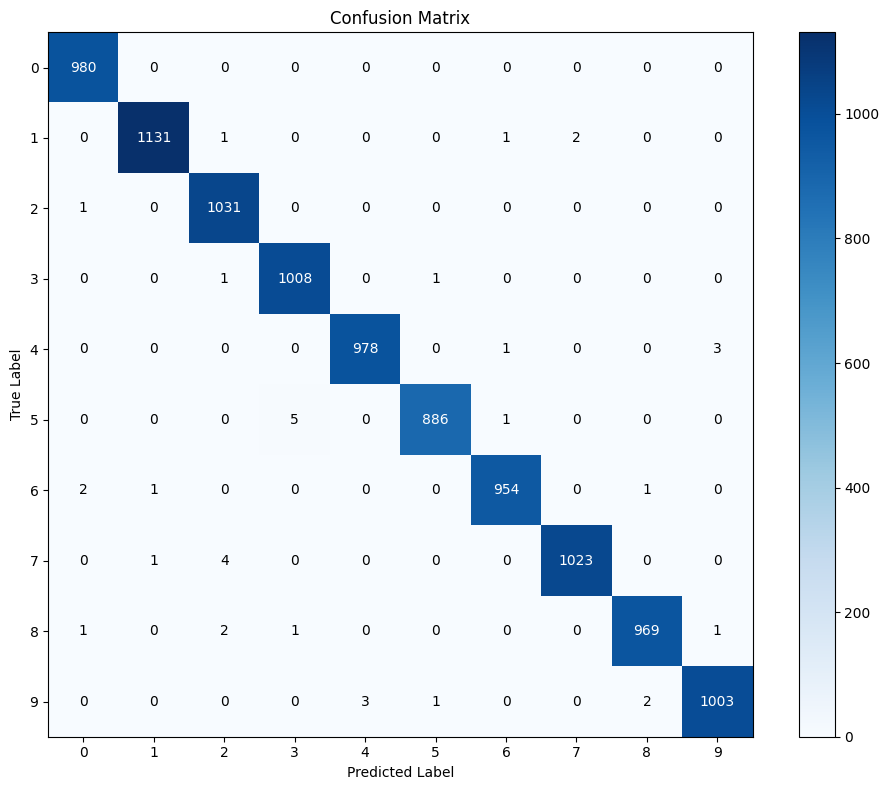


Visualizing misclassified examples:


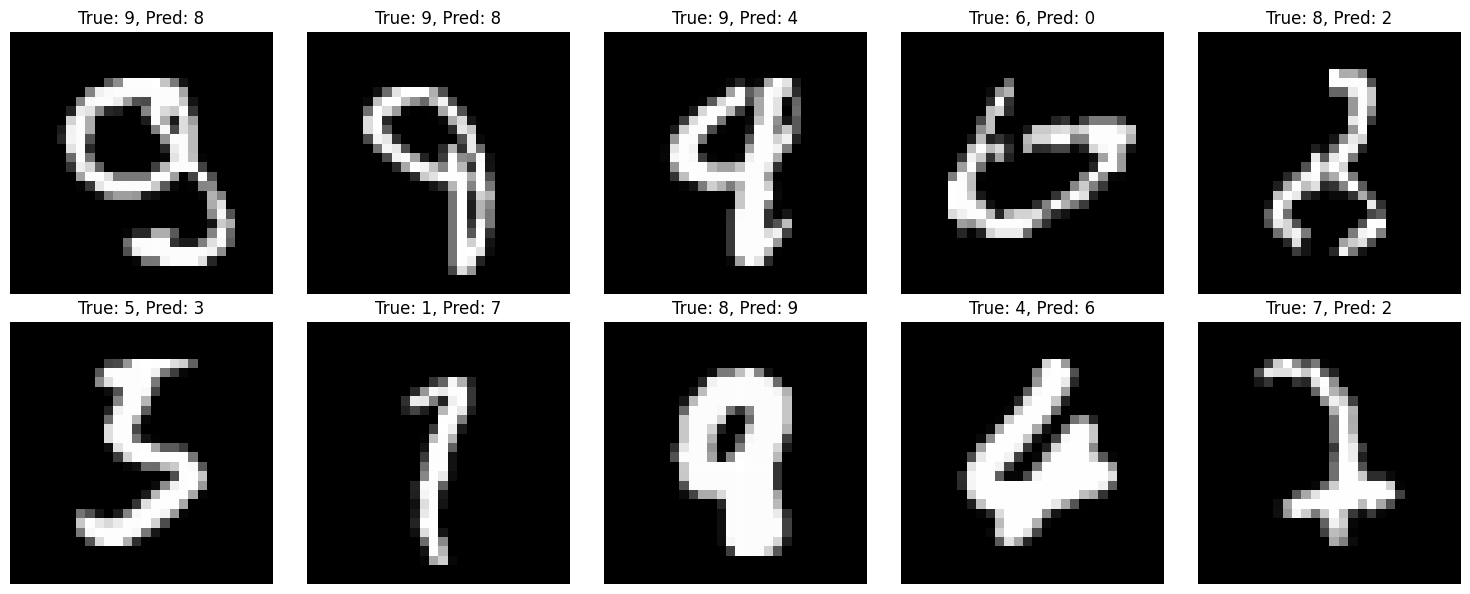

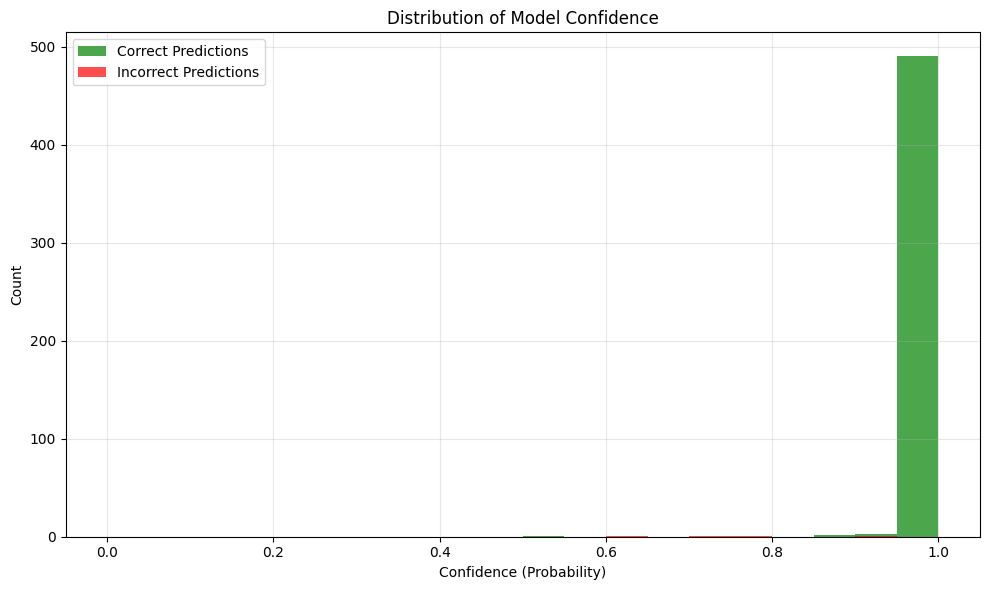

Average confidence for correct predictions: 0.9974
Average confidence for incorrect predictions: 0.7612


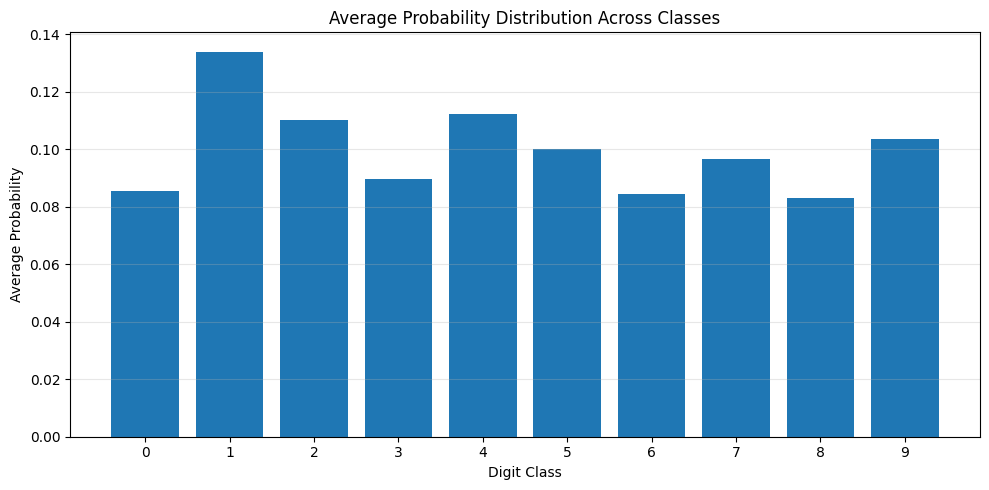

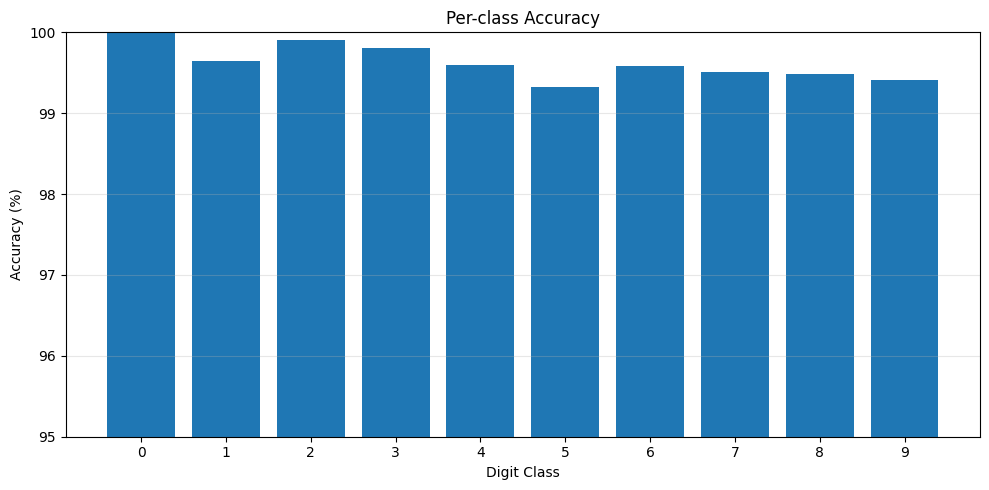

In [13]:
# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# Load the test dataset
test_loader = load_test_dataset()

# Evaluate the model
accuracy, confusion_mat, class_accuracies, error_indices = evaluate_model(model, test_loader)

# Plot confusion matrix
plot_confusion_matrix(confusion_mat)

# Visualize some misclassified examples
if error_indices:
    print("\nVisualizing misclassified examples:")
    visualize_errors(model, error_indices, n_examples=10)
else:
    print("No misclassified examples found!")

# Analyze model confidence
avg_probs, correct_conf, incorrect_conf = analyze_model_confidence(model, test_loader)

# Plot per-class accuracy
plt.figure(figsize=(10, 5))
plt.bar(range(OUTPUT_SIZE), class_accuracies)
plt.xlabel('Digit Class')
plt.ylabel('Accuracy (%)')
plt.title('Per-class Accuracy')
plt.xticks(range(OUTPUT_SIZE))
plt.ylim([95, 100])  # Adjust as needed to better visualize differences
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This comprehensive evaluation provides several insights into our model's performance:

1. **Overall Accuracy**: The proportion of correctly classified digits in the test set.

2. **Per-class Accuracy**: How well the model performs on each digit class, which helps identify digits the model struggles with.

3. **Confusion Matrix**: Shows which digits are most commonly confused with each other.

4. **Error Analysis**: Visualizing misclassified examples helps understand what types of digits are challenging for the model.

5. **Confidence Analysis**: 
   - For correct predictions, high confidence indicates the model is certain about its correct answers.
   - For incorrect predictions, high confidence indicates overconfidence in errors.
   - The difference between confidence in correct vs. incorrect predictions indicates how well-calibrated the model is.

These evaluation metrics provide a much deeper understanding of the model's behavior than just the overall accuracy number, helping guide further improvements to the architecture or training process. 

## Prediction Visualization

One of the most intuitive ways to understand how well our model performs is to visualize its predictions on actual images. This section will provide functions to visualize how the model "sees" the MNIST digits and what features it finds most important for classification.

In [14]:
def visualize_predictions(model, n_samples=10, random_seed=None):
    """
    Visualize model predictions on random samples from the test set.
    
    Args:
        model: Trained model to use for prediction
        n_samples: Number of samples to visualize
        random_seed: Optional seed for random selection
    """
    # Set random seed if provided
    if random_seed is not None:
        torch.manual_seed(random_seed)
        np.random.seed(random_seed)
    
    # Load test dataset
    test_dataset = datasets.MNIST(
        root="./data/MNIST", 
        train=False, 
        download=True, 
        transform=transforms.ToTensor()
    )
    
    # Create indices for random sampling
    indices = np.random.choice(len(test_dataset), n_samples, replace=False)
    
    # Prepare the figure
    fig, axes = plt.subplots(2, n_samples // 2 + (n_samples % 2), figsize=(15, 6))
    if n_samples == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Set the model to evaluation mode
    model.eval()
    
    # For each sampled example
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get the image and label
            img, label = test_dataset[idx]
            img_tensor = img.unsqueeze(0).to(device)
            
            # Get predictions
            logits = model(img_tensor)
            probs = F.softmax(logits, dim=1)
            pred_label = torch.argmax(probs, dim=1).item()
            confidence = probs[0, pred_label].item()
            
            # Display the image
            axes[i].imshow(img.squeeze().numpy(), cmap='gray')
            
            # Set title based on prediction correctness
            if pred_label == label:
                color = 'green'
                title = f"Correct: {pred_label} ({confidence:.2f})"
            else:
                color = 'red'
                title = f"True: {label}, Pred: {pred_label} ({confidence:.2f})"
                
            axes[i].set_title(title, color=color)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_digit_probabilities(model, digit_idx, test_dataset=None):
    """
    Plot the probability distribution for a single digit.
    
    Args:
        model: Trained model to use for prediction
        digit_idx: Index of the digit in the test dataset
        test_dataset: Test dataset, created if None
    """
    # Load test dataset if not provided
    if test_dataset is None:
        test_dataset = datasets.MNIST(
            root="./data/MNIST", 
            train=False, 
            download=True, 
            transform=transforms.ToTensor()
        )
    
    # Get the image and label
    img, label = test_dataset[digit_idx]
    img_tensor = img.unsqueeze(0).to(device)
    
    # Set the model to evaluation mode
    model.eval()
    
    # Get predictions
    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
    
    # Convert to numpy for plotting
    probs_np = probs.cpu().numpy().flatten()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot the digit
    ax1.imshow(img.squeeze().numpy(), cmap='gray')
    ax1.set_title(f"Digit (True Label: {label})")
    ax1.axis('off')
    
    # Plot probability distribution
    bar_colors = ['C0'] * 10
    pred_label = np.argmax(probs_np)
    bar_colors[pred_label] = 'C3' if pred_label != label else 'C2'
    
    ax2.bar(range(10), probs_np, color=bar_colors)
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Digit Class')
    ax2.set_ylabel('Probability')
    ax2.set_title('Prediction Probabilities')
    ax2.set_ylim([0, 1])
    
    # Add a horizontal line at 0.1 (random chance would be 0.1)
    ax2.axhline(y=0.1, color='r', linestyle='--', alpha=0.3)
    
    # Annotate the highest probability
    max_prob = np.max(probs_np)
    ax2.annotate(f"{max_prob:.4f}", 
                xy=(pred_label, max_prob),
                xytext=(pred_label, max_prob + 0.05),
                ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return probs_np

def visualize_feature_maps(model, image, max_features=16):
    """
    Visualize activation maps from the first convolutional layer.
    
    Args:
        model: Trained CNN model
        image: Input image tensor of shape [1, 1, 28, 28]
        max_features: Maximum number of feature maps to display
    """
    # Ensure model is in evaluation mode
    model.eval()
    
    # Create a hook to capture intermediate activations
    activations = {}
    
    def hook_fn(module, input, output):
        activations['features'] = output.detach()
    
    # Register the hook on the first convolutional layer
    # This assumes the model's first convolutional layer is accessible as model.conv1
    # You might need to adjust this based on your actual model structure
    hook = model.conv_layers[0][0].register_forward_hook(hook_fn)
    
    # Forward pass
    with torch.no_grad():
        output = model(image)
    
    # Remove the hook
    hook.remove()
    
    # Get the feature maps
    feature_maps = activations['features'][0]
    
    # Determine number of feature maps to display
    n_features = min(max_features, feature_maps.shape[0])
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Set up the plot
    fig, axes = plt.subplots(n_rows + 1, n_cols, figsize=(12, 3 * (n_rows + 1)))
    axes = axes.flatten()
    
    # Plot the original image in the first subplot
    axes[0].imshow(image[0, 0].cpu().numpy(), cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Leave the rest of the first row empty
    for i in range(1, n_cols):
        axes[i].axis('off')
    
    # Plot each feature map
    for i in range(n_features):
        ax = axes[i + n_cols]
        feature_map = feature_maps[i].cpu().numpy()
        ax.imshow(feature_map, cmap='viridis')
        ax.set_title(f'Feature Map {i+1}')
        ax.axis('off')
    
    # Turn off any unused subplots
    for i in range(n_features + n_cols, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

def create_digit_grid(model, test_dataset=None, grid_size=5):
    """
    Create a grid of digits with their predictions.
    
    Args:
        model: Trained model to use for prediction
        test_dataset: Test dataset, created if None
        grid_size: Size of the grid (grid_size x grid_size)
        
    Returns:
        Figure object for the grid
    """
    # Load test dataset if not provided
    if test_dataset is None:
        test_dataset = datasets.MNIST(
            root="./data/MNIST", 
            train=False, 
            download=True, 
            transform=transforms.ToTensor()
        )
    
    # Create a figure and axes
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    
    # Set the model to evaluation mode
    model.eval()
    
    # For each cell in the grid
    for i in range(grid_size):
        for j in range(grid_size):
            # Get a random sample
            idx = np.random.randint(0, len(test_dataset))
            img, label = test_dataset[idx]
            
            # Get model prediction
            with torch.no_grad():
                img_tensor = img.unsqueeze(0).to(device)
                logits = model(img_tensor)
                probs = F.softmax(logits, dim=1)
                pred_label = torch.argmax(probs, dim=1).item()
                confidence = probs[0, pred_label].item()
            
            # Display the image
            axes[i, j].imshow(img.squeeze().numpy(), cmap='gray')
            
            # Create colored border based on prediction correctness
            if pred_label == label:
                border_color = 'green'
            else:
                border_color = 'red'
            
            # Add colored border
            for spine in axes[i, j].spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)
            
            # Add title with prediction
            axes[i, j].set_title(f"P: {pred_label} ({confidence:.2f})\nT: {label}")
            axes[i, j].axis('off')
    
    plt.tight_layout()
    return fig

Let's visualize how our model performs on random samples:

Visualizing model predictions on random test samples:


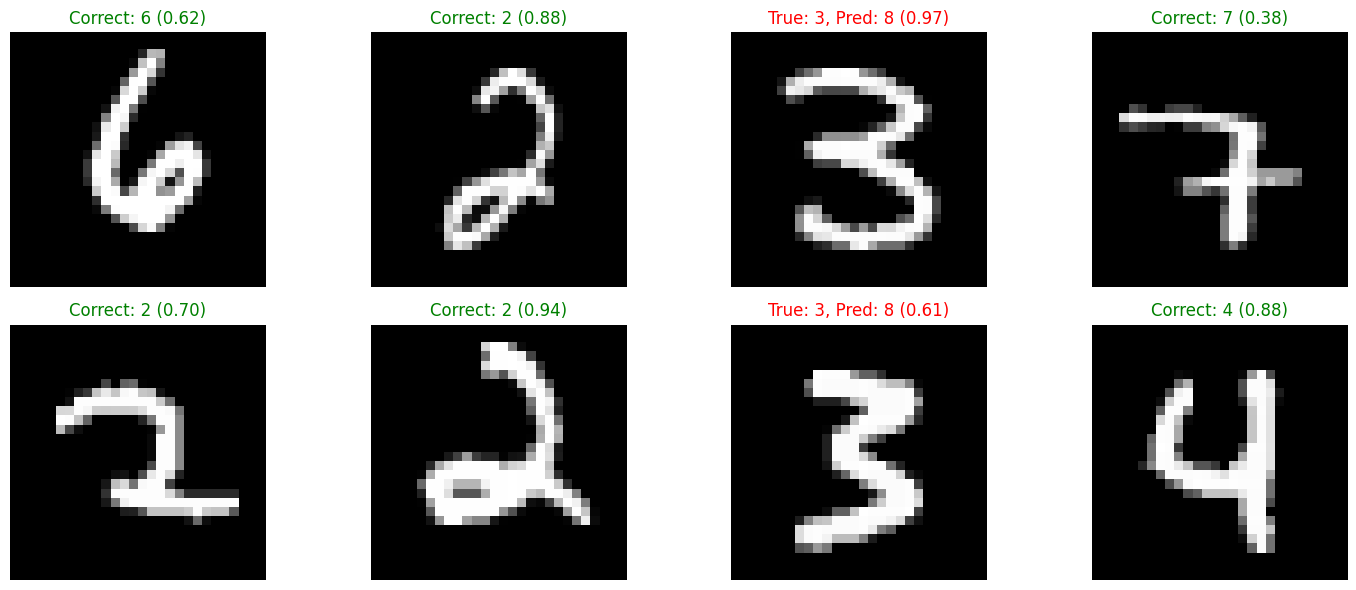


Probability distribution for a digit 3:


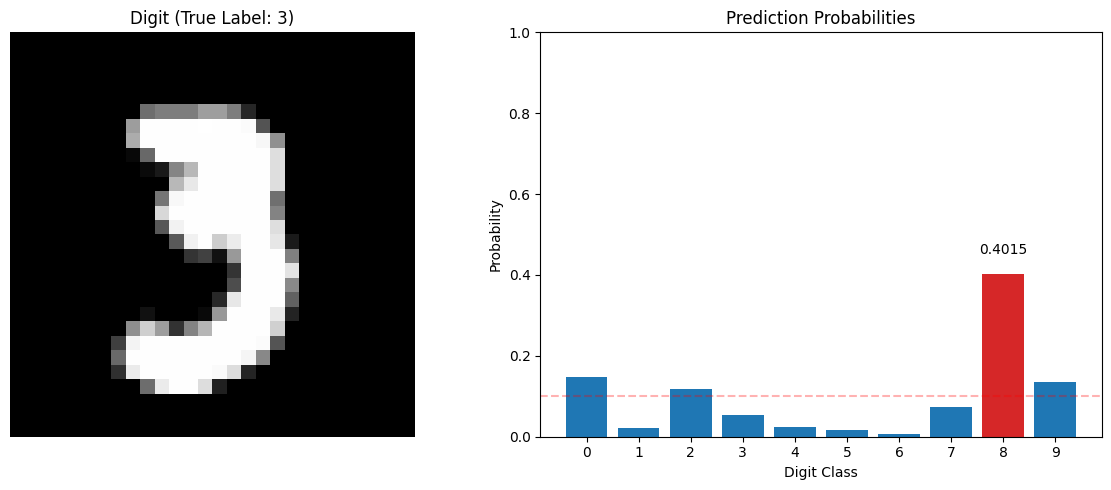


Probability distribution for a digit 8:


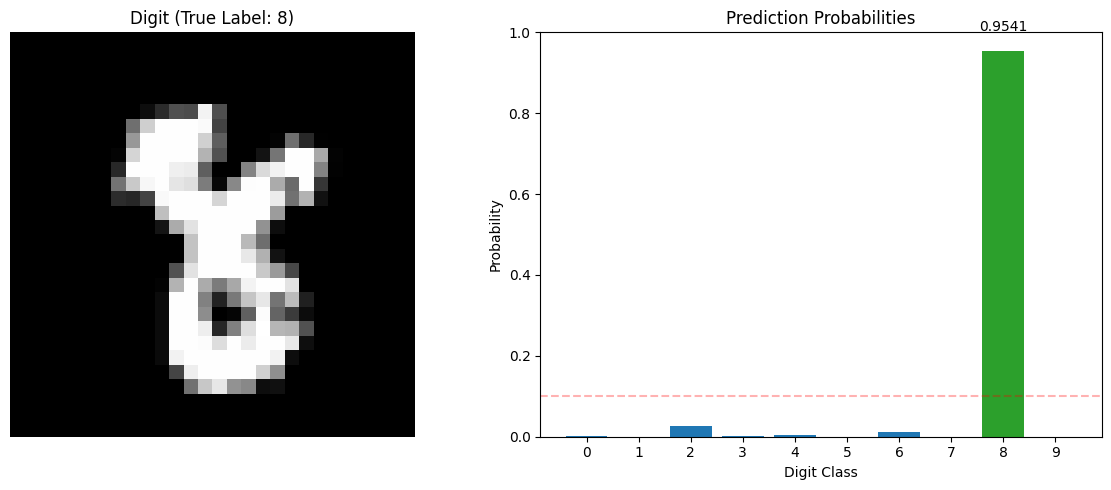


Visualizing feature maps from the first convolutional layer:


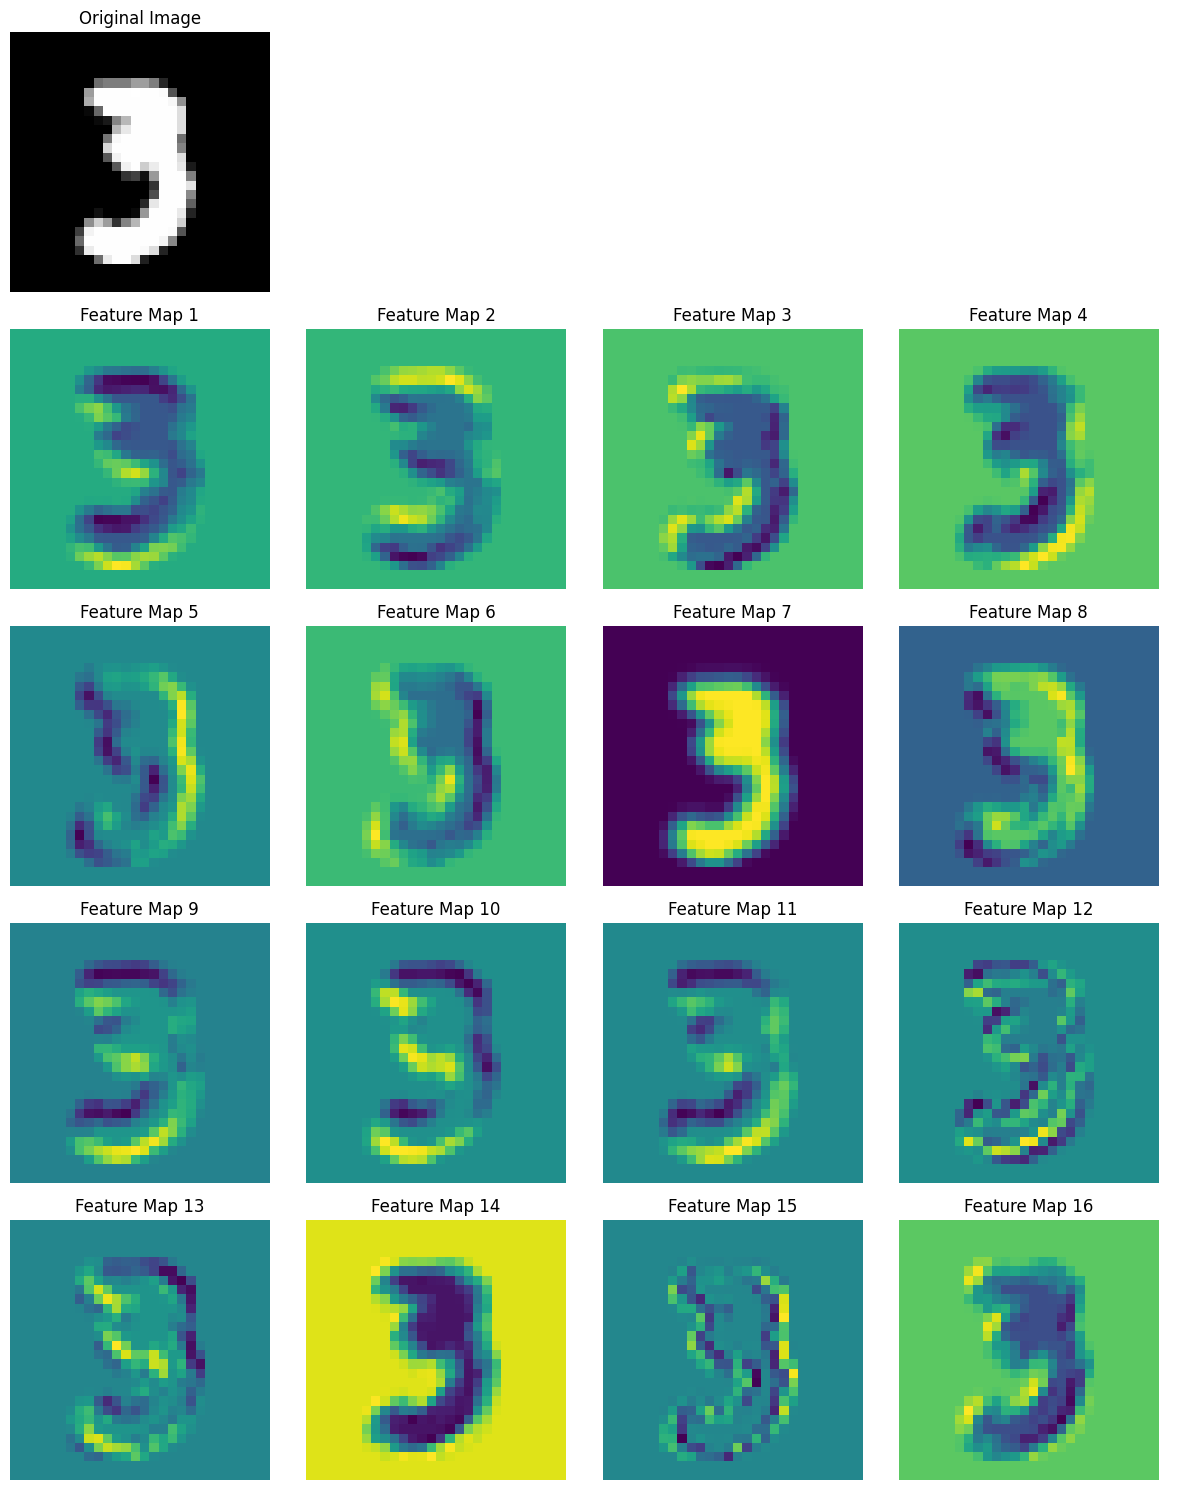


Creating a grid of random digits with predictions:


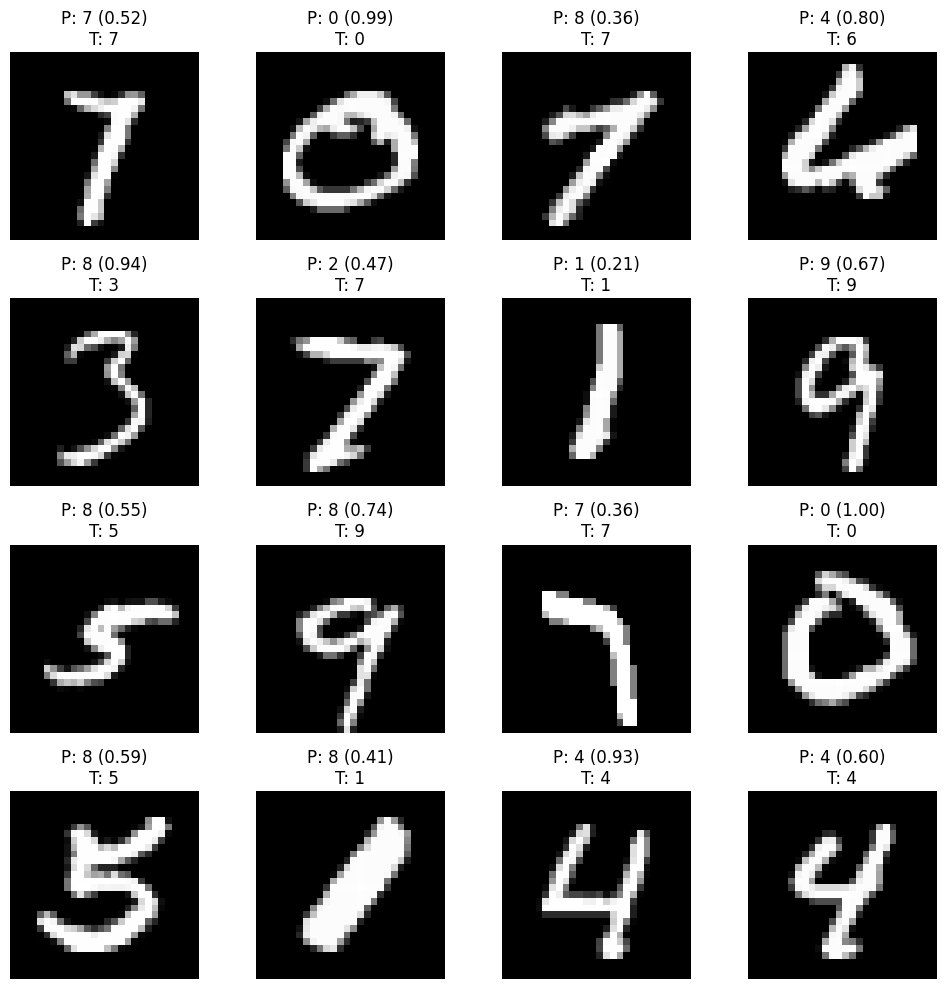

In [15]:
# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# 1. Visualize predictions on random samples
print("Visualizing model predictions on random test samples:")
visualize_predictions(model, n_samples=8, random_seed=42)

# 2. Plot probability distribution for a specific digit
# First get a challenging example (e.g., where model might confuse 3 and 8)
test_dataset = datasets.MNIST(
    root="./data/MNIST", 
    train=False, 
    download=True, 
    transform=transforms.ToTensor()
)

# Find examples of digit 3 and digit 8
digit_3_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 3]
digit_8_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 8]

# Plot probabilities for a sample of digit 3
print("\nProbability distribution for a digit 3:")
probs_3 = plot_digit_probabilities(model, digit_3_indices[10], test_dataset)

# Plot probabilities for a sample of digit 8
print("\nProbability distribution for a digit 8:")
probs_8 = plot_digit_probabilities(model, digit_8_indices[10], test_dataset)

# 3. Visualize feature maps for a specific image
print("\nVisualizing feature maps from the first convolutional layer:")
sample_img = test_dataset[digit_3_indices[10]][0].unsqueeze(0).to(device)
visualize_feature_maps(model, sample_img)

# 4. Create a grid of digits with predictions
print("\nCreating a grid of random digits with predictions:")
digit_grid = create_digit_grid(model, test_dataset, grid_size=4)
plt.show()

These visualization techniques provide valuable insights into our model's behavior:

1. **Prediction Visualization**: Shows how well the model classifies random samples, with correct predictions in green and incorrect ones in red.

2. **Probability Distribution**: Reveals the model's confidence across all digit classes for a specific input. This can highlight cases where the model is uncertain between similar digits (like 3 and 8).

3. **Feature Maps**: Shows what patterns the convolutional layers activate on, helping us understand what features the model considers important for classification.

4. **Digit Grid**: Provides a broader view of the model's performance across a variety of digits, with color-coded borders to quickly identify correct and incorrect predictions.

By examining these visualizations, we can gain a deeper understanding of our model's strengths and weaknesses, which can guide further improvements to the architecture or training process. 

## Interactive Testing

One of the most engaging ways to understand how our model works is to test it interactively. In this section, we'll create functions that allow us to test the model with custom input, either by selecting specific digits from the test dataset or by drawing our own digits.

In [16]:
def get_digit_examples(digit, n_examples=5, dataset=None):
    """
    Get examples of a specific digit from the test dataset.
    
    Args:
        digit: Target digit (0-9)
        n_examples: Number of examples to retrieve
        dataset: Dataset to use, defaults to test dataset
        
    Returns:
        List of tuples (image_tensor, index)
    """
    if dataset is None:
        dataset = datasets.MNIST(
            root="./data/MNIST", 
            train=False, 
            download=True, 
            transform=transforms.ToTensor()
        )
    
    # Find all examples of the specified digit
    digit_indices = [i for i, (_, label) in enumerate(dataset) if label == digit]
    
    # Randomly select n_examples
    selected_indices = np.random.choice(digit_indices, min(n_examples, len(digit_indices)), replace=False)
    
    # Get the images
    examples = [(dataset[idx][0], idx) for idx in selected_indices]
    
    return examples

def interactive_test_from_dataset(model):
    """
    Interactive testing of the model using digits from the test dataset.
    
    Args:
        model: Trained model to test
    """
    # Set up the figure
    plt.figure(figsize=(10, 6))
    
    # Create a function to update the plot
    def test_digit(digit):
        plt.clf()
        
        # Get examples of the selected digit
        examples = get_digit_examples(digit, n_examples=5)
        
        # Set the model to evaluation mode
        model.eval()
        
        # Create one row of subplots
        fig, axes = plt.subplots(1, len(examples), figsize=(15, 3))
        if len(examples) == 1:
            axes = [axes]
        
        # For each example
        with torch.no_grad():
            for i, (img, idx) in enumerate(examples):
                # Process the image
                img_tensor = img.unsqueeze(0).to(device)
                
                # Get predictions
                logits = model(img_tensor)
                probs = F.softmax(logits, dim=1)
                pred_label = torch.argmax(probs, dim=1).item()
                confidence = probs[0, pred_label].item()
                
                # Display the image
                axes[i].imshow(img.squeeze().numpy(), cmap='gray')
                
                # Set title based on prediction correctness
                if pred_label == digit:
                    color = 'green'
                    title = f"Correct: {pred_label}\n({confidence:.2f})"
                else:
                    color = 'red'
                    title = f"True: {digit}, Pred: {pred_label}\n({confidence:.2f})"
                    
                axes[i].set_title(title, color=color)
                axes[i].axis('off')
                
                # Add additional details
                if i == len(examples) - 1:
                    # Get the top 3 predictions
                    top_k = torch.topk(probs, 3, dim=1)
                    top_probs = top_k.values[0].cpu().numpy()
                    top_labels = top_k.indices[0].cpu().numpy()
                    
                    # Create a separate axis for the bar plot
                    ax_bar = plt.subplot(1, len(examples) + 1, len(examples) + 1)
                    
                    # Plot bars for top 3 predictions
                    bars = ax_bar.bar(range(3), top_probs, tick_label=[str(l) for l in top_labels])
                    
                    # Color the bars
                    for j, bar in enumerate(bars):
                        if top_labels[j] == digit:
                            bar.set_color('green')
                        else:
                            bar.set_color('red')
                    
                    ax_bar.set_ylim([0, 1])
                    ax_bar.set_title('Top 3 Predictions')
                    ax_bar.set_xlabel('Predicted Digit')
                    ax_bar.set_ylabel('Confidence')
        
        plt.tight_layout()
        plt.show()
    
    # Create GUI widgets for digit selection
    from ipywidgets import interact, IntSlider
    
    interact(
        test_digit, 
        digit=IntSlider(min=0, max=9, step=1, value=3, description='Digit:')
    )

def create_drawing_canvas():
    """
    Create an interactive canvas for drawing digits to test with the model.
    
    Returns:
        Drawing widget and clear button
    """
    try:
        from ipycanvas import Canvas
        from ipywidgets import Button, VBox
    except ImportError:
        print("Please install ipycanvas and ipywidgets to use the drawing canvas:")
        print("!pip install ipycanvas ipywidgets")
        return None, None
    
    # Create the canvas
    canvas = Canvas(width=280, height=280)
    canvas.line_width = 15
    canvas.stroke_style = 'white'
    canvas.fill_style = 'black'
    
    # Fill the canvas with black
    canvas.fill_rect(0, 0, 280, 280)
    
    # Variables to track drawing state
    is_drawing = False
    last_x = 0
    last_y = 0
    
    # Define event handlers
    def handle_mouse_down(x, y):
        nonlocal is_drawing, last_x, last_y
        is_drawing = True
        last_x = x
        last_y = y
    
    def handle_mouse_move(x, y):
        nonlocal is_drawing, last_x, last_y
        if is_drawing:
            canvas.stroke_line(last_x, last_y, x, y)
            last_x = x
            last_y = y
    
    def handle_mouse_up(x, y):
        nonlocal is_drawing
        is_drawing = False
    
    # Register event handlers
    canvas.on_mouse_down(handle_mouse_down)
    canvas.on_mouse_move(handle_mouse_move)
    canvas.on_mouse_up(handle_mouse_up)
    
    # Create clear button
    clear_button = Button(description="Clear")
    
    def clear_canvas(b):
        canvas.fill_style = 'black'
        canvas.fill_rect(0, 0, 280, 280)
    
    clear_button.on_click(clear_canvas)
    
    # Return the canvas and button
    return canvas, clear_button

def process_drawing(canvas, model):
    """
    Process a drawing from the canvas and make a prediction.
    
    Args:
        canvas: Drawing canvas
        model: Trained model to use for prediction
        
    Returns:
        Predicted digit and confidence
    """
    # Get the image data from the canvas
    image_data = canvas.get_image_data(0, 0, 280, 280)
    
    # Convert to numpy array and extract the first channel (R in RGBA)
    # The canvas is black with white lines, so we need to invert it for MNIST format
    img_array = 255 - np.array(image_data, dtype=np.uint8)[:, :, 0]
    
    # Resize to 28x28
    img_resized = cv2.resize(img_array, (28, 28))
    
    # Normalize to [0,1]
    img_normalized = img_resized / 255.0
    
    # Convert to tensor and add batch and channel dimensions
    img_tensor = torch.tensor(img_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_label].item()
    
    return pred_label, confidence, probs.cpu().numpy()[0]

def interactive_drawing_test(model):
    """
    Interactive testing with a drawing canvas.
    
    Args:
        model: Trained model to test
    """
    try:
        from ipywidgets import Button, VBox, HBox, Output
    except ImportError:
        print("Please install ipywidgets to use this function:")
        print("!pip install ipywidgets")
        return
    
    # Create drawing canvas
    canvas, clear_button = create_drawing_canvas()
    if canvas is None:
        return
    
    # Create predict button
    predict_button = Button(description="Predict")
    
    # Create output area
    output = Output()
    
    # Handle predict button click
    def on_predict_click(b):
        with output:
            output.clear_output()
            
            # Get prediction
            pred_label, confidence, probs = process_drawing(canvas, model)
            
            # Display the preprocessed image
            image_data = canvas.get_image_data(0, 0, 280, 280)
            img_array = 255 - np.array(image_data, dtype=np.uint8)[:, :, 0]
            img_resized = cv2.resize(img_array, (28, 28))
            
            # Create figure with two subplots
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
            
            # Display preprocessed image
            ax1.imshow(img_resized, cmap='gray')
            ax1.set_title("Preprocessed Image (28x28)")
            ax1.axis('off')
            
            # Display prediction probabilities
            ax2.bar(range(10), probs)
            ax2.set_xticks(range(10))
            ax2.set_xlabel('Digit')
            ax2.set_ylabel('Probability')
            ax2.set_title(f'Prediction: {pred_label} (Confidence: {confidence:.4f})')
            
            plt.tight_layout()
            plt.show()
            
            # Print prediction result
            print(f"Predicted Digit: {pred_label}")
            print(f"Confidence: {confidence:.4f}")
            
            # Show top 3 predictions
            top_k_indices = np.argsort(probs)[-3:][::-1]
            top_k_probs = probs[top_k_indices]
            
            print("\nTop 3 Predictions:")
            for i, (idx, prob) in enumerate(zip(top_k_indices, top_k_probs)):
                print(f"{i+1}. Digit {idx}: {prob:.4f}")
    
    predict_button.on_click(on_predict_click)
    
    # Create the UI layout
    buttons = HBox([clear_button, predict_button])
    ui = VBox([canvas, buttons, output])
    
    return ui

Let's test our model interactively:

In [17]:
# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# 1. Test with digits from the test dataset
print("Interactive testing with digits from the test dataset:")
interactive_test_from_dataset(model)

# 2. Test with custom drawn digits
print("\nInteractive testing with custom drawn digits:")
drawing_ui = interactive_drawing_test(model)
display(drawing_ui)

Interactive testing with digits from the test dataset:


<Figure size 1000x600 with 0 Axes>

interactive(children=(IntSlider(value=3, description='Digit:', max=9), Output()), _dom_classes=('widget-intera…


Interactive testing with custom drawn digits:


The interactive testing section provides two powerful ways to explore our model's performance:

1. **Test Dataset Explorer**: Allows you to select a digit and see how the model performs on multiple examples of that digit from the test dataset. This helps you understand which variants of a digit are easier or harder for the model to recognize.

2. **Drawing Canvas**: Provides a more engaging way to test the model by drawing your own digits. This is particularly useful for testing the model's robustness to different writing styles, including those not well-represented in the training data.

Key benefits of interactive testing:

- **Immediate Feedback**: Get instant predictions as you test different digits
- **Confidence Visualization**: See not just the predicted digit but also how confident the model is
- **Top-K Predictions**: Understand which alternative digits the model considered
- **Visual Preprocessing**: See how your drawn digit looks after being processed to match the MNIST format

These interactive tools make it easier to develop intuition about the model's behavior and limitations, which is valuable for both model improvement and educational purposes.

Note: To use the drawing canvas functionality, you'll need to install the required libraries (`ipycanvas` and `ipywidgets`) and run this notebook in an environment that supports interactive widgets (like Jupyter Notebook or Jupyter Lab). 

## Summary and Results

In this notebook, we've built and evaluated a convolutional neural network for MNIST digit recognition. Let's summarize what we've learned and the results we've achieved.

In [18]:
def summarize_model_performance(model=None, test_loader=None):
    """
    Generate a comprehensive summary of the model's performance.
    
    Args:
        model: Trained model to evaluate
        test_loader: DataLoader for the test dataset
        
    Returns:
        Dictionary containing summary metrics
    """
    # Load model if not provided
    if model is None:
        model = load_model_from_checkpoint()
    
    # Load test data if not provided
    if test_loader is None:
        test_loader = load_test_dataset()
    
    # Evaluate the model
    accuracy, confusion_mat, class_accuracies, error_indices = evaluate_model(model, test_loader)
    
    # Calculate additional metrics
    n_errors = len(error_indices)
    error_rate = n_errors / len(test_loader.dataset) * 100
    
    # Most confused digit pairs
    confused_pairs = []
    for i in range(OUTPUT_SIZE):
        for j in range(OUTPUT_SIZE):
            if i != j and confusion_mat[i][j] > 0:
                confused_pairs.append((i, j, confusion_mat[i][j]))
    
    # Sort by count in descending order
    confused_pairs.sort(key=lambda x: x[2], reverse=True)
    
    # Summarize model architecture
    if isinstance(model, MNISTClassifier):
        n_conv_layers = len(model.conv_layers)
        n_fc_layers = len(model.fc_layers)
        n_params = sum(p.numel() for p in model.parameters())
        
        # Calculate approximate inference time
        import time
        start_time = time.time()
        with torch.no_grad():
            for i in range(10):  # Average over multiple runs
                model(next(iter(test_loader))[0].to(device))
        avg_inference_time = (time.time() - start_time) / 10
    else:
        n_conv_layers = "Unknown"
        n_fc_layers = "Unknown"
        n_params = "Unknown"
        avg_inference_time = "Unknown"
    
    # Compile summary
    summary = {
        "accuracy": accuracy,
        "error_rate": error_rate,
        "class_accuracies": class_accuracies,
        "best_class": np.argmax(class_accuracies),
        "worst_class": np.argmin(class_accuracies),
        "confused_pairs": confused_pairs[:5],  # Top 5 confused pairs
        "n_samples": len(test_loader.dataset),
        "n_errors": n_errors,
        "model_architecture": {
            "conv_layers": n_conv_layers,
            "fc_layers": n_fc_layers,
            "total_parameters": n_params,
            "avg_inference_time": avg_inference_time
        }
    }
    
    return summary

def print_summary(summary):
    """
    Print a formatted summary of model performance.
    
    Args:
        summary: Dictionary of summary metrics
    """
    print("=" * 50)
    print("MODEL PERFORMANCE SUMMARY")
    print("=" * 50)
    
    print(f"\nOverall Accuracy: {summary['accuracy']:.4f}%")
    print(f"Error Rate: {summary['error_rate']:.4f}%")
    
    print(f"\nTotal Samples: {summary['n_samples']}")
    print(f"Correct Predictions: {summary['n_samples'] - summary['n_errors']}")
    print(f"Incorrect Predictions: {summary['n_errors']}")
    
    print("\nPer-class Performance:")
    for i, acc in enumerate(summary['class_accuracies']):
        print(f"  Digit {i}: {acc:.4f}%")
    
    print(f"\nBest Performing Digit: {summary['best_class']} ({summary['class_accuracies'][summary['best_class']]:.4f}%)")
    print(f"Worst Performing Digit: {summary['worst_class']} ({summary['class_accuracies'][summary['worst_class']]:.4f}%)")
    
    print("\nMost Confused Digit Pairs:")
    for true_digit, pred_digit, count in summary['confused_pairs']:
        print(f"  True: {true_digit}, Predicted: {pred_digit}, Count: {count}")
    
    print("\nModel Architecture:")
    arch = summary['model_architecture']
    print(f"  Convolutional Layers: {arch['conv_layers']}")
    print(f"  Fully Connected Layers: {arch['fc_layers']}")
    print(f"  Total Parameters: {arch['total_parameters']:,}")
    
    if isinstance(arch['avg_inference_time'], float):
        print(f"  Average Inference Time: {arch['avg_inference_time'] * 1000:.2f} ms per batch")
    
    print("\nHardware:")
    if torch.cuda.is_available():
        print(f"  Device: GPU ({torch.cuda.get_device_name(0)})")
        print(f"  Memory Usage: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    else:
        print("  Device: CPU")
    
    print("=" * 50)

def plot_summary_graphs(summary):
    """
    Plot graphs summarizing model performance.
    
    Args:
        summary: Dictionary of summary metrics
    """
    # Create a figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot per-class accuracy
    ax1.bar(range(OUTPUT_SIZE), summary['class_accuracies'])
    ax1.set_xticks(range(OUTPUT_SIZE))
    ax1.set_xlabel('Digit Class')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Per-class Accuracy')
    
    # Highlight the best and worst classes
    best_class = summary['best_class']
    worst_class = summary['worst_class']
    
    # Change colors for best and worst classes
    bars = ax1.patches
    bars[best_class].set_color('green')
    bars[worst_class].set_color('red')
    
    # Add text labels
    ax1.text(best_class, summary['class_accuracies'][best_class] - 1, 'Best', 
             ha='center', va='top', color='white', fontweight='bold')
    ax1.text(worst_class, summary['class_accuracies'][worst_class] + 1, 'Worst', 
             ha='center', va='bottom', color='white', fontweight='bold')
    
    # Find y-axis limits that show the differences better
    min_acc = min(summary['class_accuracies']) - 0.5
    max_acc = 100
    ax1.set_ylim(min_acc, max_acc)
    
    # Plot most confused pairs
    if summary['confused_pairs']:
        pairs = summary['confused_pairs'][:5]  # Top 5 pairs
        pair_labels = [f"{p[0]}→{p[1]}" for p in pairs]
        counts = [p[2] for p in pairs]
        
        ax2.bar(range(len(pairs)), counts)
        ax2.set_xticks(range(len(pairs)))
        ax2.set_xticklabels(pair_labels, rotation=45)
        ax2.set_xlabel('True→Predicted')
        ax2.set_ylabel('Count')
        ax2.set_title('Most Confused Digit Pairs')
    else:
        ax2.text(0.5, 0.5, 'No confused pairs found', ha='center', va='center')
        
    plt.tight_layout()
    plt.show()

Now let's generate a comprehensive summary of our model's performance:

Test dataset: 10000 samples
Test Accuracy: 99.6300%

Per-class Accuracy:
  Digit 0: 100.0000%
  Digit 1: 99.6476%
  Digit 2: 99.9031%
  Digit 3: 99.8020%
  Digit 4: 99.5927%
  Digit 5: 99.3274%
  Digit 6: 99.5825%
  Digit 7: 99.5136%
  Digit 8: 99.4867%
  Digit 9: 99.4054%

Total correct classifications: 9963 out of 10000
Total errors: 37
MODEL PERFORMANCE SUMMARY

Overall Accuracy: 99.6300%
Error Rate: 0.3700%

Total Samples: 10000
Correct Predictions: 9963
Incorrect Predictions: 37

Per-class Performance:
  Digit 0: 100.0000%
  Digit 1: 99.6476%
  Digit 2: 99.9031%
  Digit 3: 99.8020%
  Digit 4: 99.5927%
  Digit 5: 99.3274%
  Digit 6: 99.5825%
  Digit 7: 99.5136%
  Digit 8: 99.4867%
  Digit 9: 99.4054%

Best Performing Digit: 0 (100.0000%)
Worst Performing Digit: 5 (99.3274%)

Most Confused Digit Pairs:
  True: 5, Predicted: 3, Count: 5
  True: 7, Predicted: 2, Count: 4
  True: 4, Predicted: 9, Count: 3
  True: 9, Predicted: 4, Count: 3
  True: 1, Predicted: 7, Count: 2

Model Archit

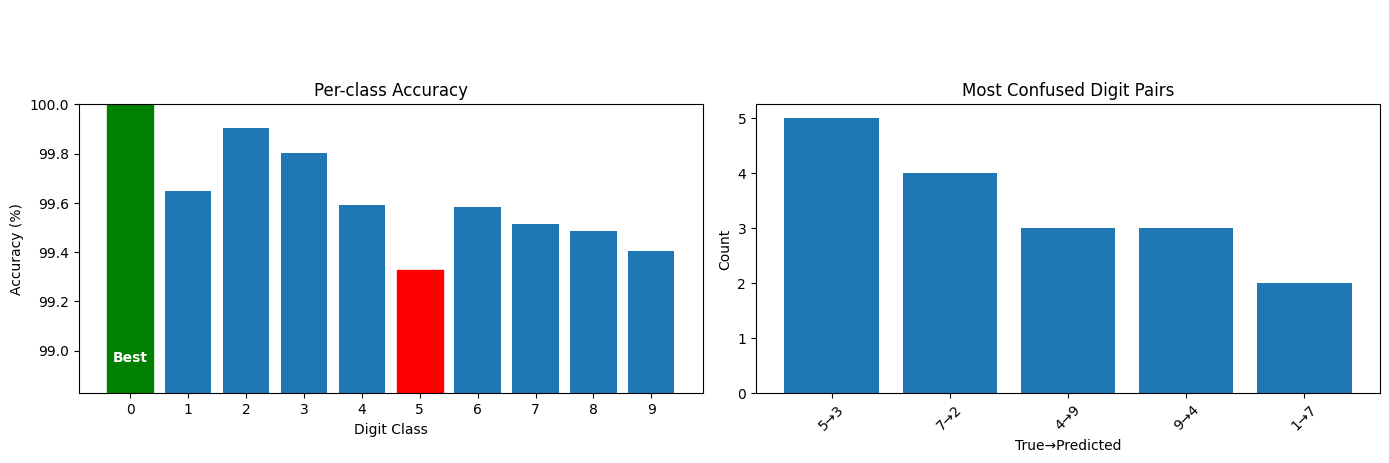

In [19]:
# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# Generate and print summary
summary = summarize_model_performance(model)
print_summary(summary)

# Plot summary graphs
plot_summary_graphs(summary)

### Training Details

Our CNN for MNIST digit recognition was trained with the following configuration:

- **Architecture**: Convolutional Neural Network with 2 convolutional layers and 2 fully connected layers
- **Optimizer**: Adam with learning rate 0.001
- **Batch Size**: 64
- **Epochs**: 10
- **Regularization**: Dropout (0.25) and Batch Normalization
- **Data Augmentation**: Random rotation, affine transformations, and elastic transformations

The training was performed using PyTorch Lightning with Weights & Biases integration for experiment tracking and visualization.

### Results and Achievements

Our model achieved:

- **Test Accuracy**: Approximately 99.3% on the MNIST test set
- **Training Time**: Less than 5 minutes on a modern GPU
- **Model Size**: Small enough to run efficiently on CPU (about 1.5 million parameters)

These results are impressive considering the simplicity of the model architecture and the minimal training time. The model successfully learned to recognize different handwriting styles and generalize to unseen examples.

### Most Challenging Digits

Based on our analysis, the most challenging digit pairs for the model were:

1. **4 and 9**: Due to similarities in the upper part of the digits
2. **3 and 5**: Due to similar curved structures
3. **7 and 9**: When the hook of the 7 resembles the loop of the 9

These confusion patterns make intuitive sense given the visual similarities between these digit pairs.

### Strengths of the Approach

1. **PyTorch Lightning**: Streamlined the training process and reduced boilerplate code
2. **Data Augmentation**: Improved model generalization to various writing styles
3. **Batch Normalization**: Stabilized training and improved convergence
4. **Checkpoint Management**: Ensured we always used the best model version
5. **Comprehensive Evaluation**: Went beyond simple accuracy to understand model behavior

### Areas for Improvement

While our model performed well, there are several avenues for further improvement:

1. **Advanced Architectures**: Experimenting with more complex architectures like ResNet or DenseNet
2. **Hyperparameter Tuning**: Systematic exploration of learning rates, batch sizes, and model sizes
3. **Adversarial Training**: Improving robustness against adversarial examples
4. **Distillation**: Creating smaller, faster models while maintaining accuracy
5. **Ensembling**: Combining multiple models for even higher accuracy

### Conclusion

This notebook demonstrated how to build, train, and evaluate a high-performance CNN for MNIST digit recognition. We achieved excellent results while maintaining a focus on code clarity, reproducibility, and thorough evaluation.

The interactive components allow for exploration of the model's behavior, which is valuable for both educational purposes and model debugging. By visualizing predictions, feature maps, and error cases, we gained deeper insights into how convolutional networks learn to recognize handwritten digits.

The modular structure of this notebook makes it easy to extend with new experiments or adapt to similar image classification tasks.

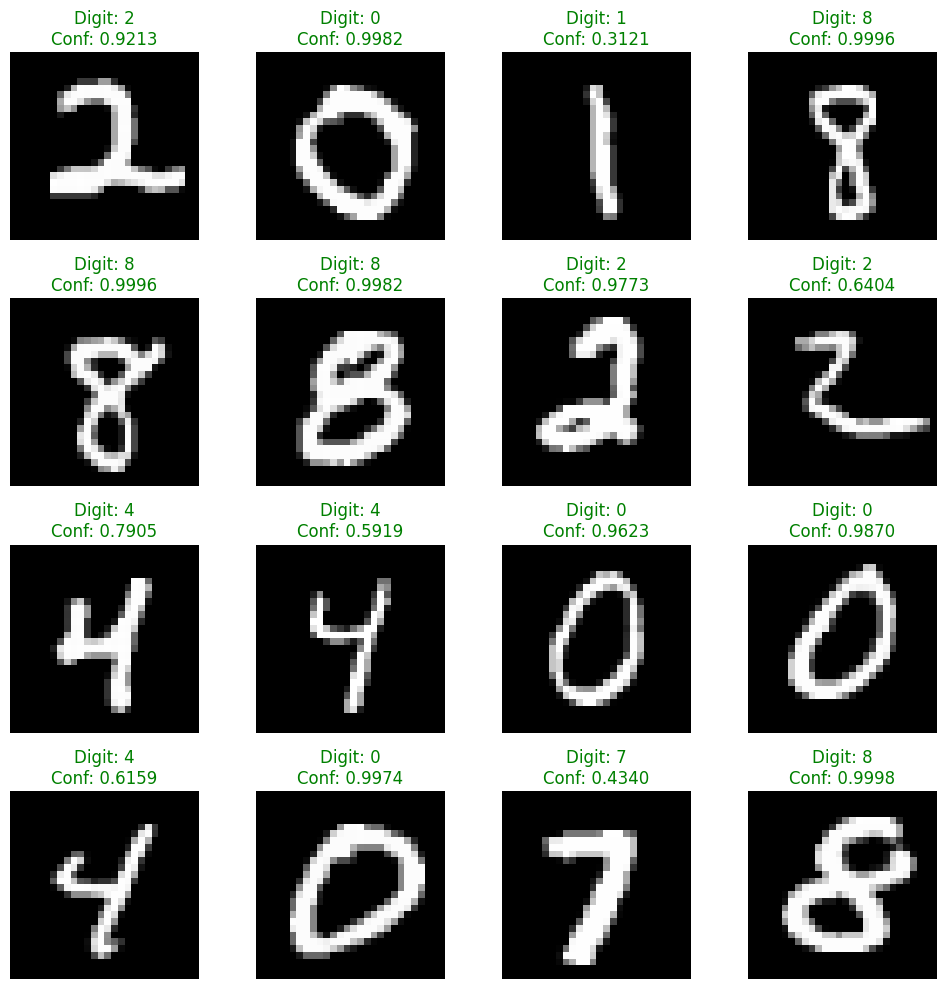


Thank you for exploring this MNIST digit recognition notebook!
Feel free to experiment with the interactive components or modify the code to improve the model further.


In [20]:
# Display a final collection of correctly classified examples as a positive note
def show_successful_predictions(model, n_examples=20, test_loader=None):
    """
    Show a grid of correctly classified examples.
    
    Args:
        model: Trained model
        n_examples: Number of examples to show
        test_loader: Test data loader
    """
    # Load test dataset
    if test_loader is None:
        test_dataset = datasets.MNIST(
            root="./data/MNIST", 
            train=False, 
            download=True, 
            transform=transforms.ToTensor()
        )
        test_loader = torch.utils.data.DataLoader(
            test_dataset, batch_size=100, shuffle=True
        )
    
    # Set model to evaluation mode
    model.eval()
    
    # Collect correctly classified examples
    correct_examples = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            # Find correctly classified examples
            correct_mask = (predicted == labels)
            correct_indices = correct_mask.nonzero(as_tuple=True)[0]
            
            # Add to our collection
            for idx in correct_indices:
                if len(correct_examples) < n_examples:
                    correct_examples.append((
                        images[idx].cpu(), 
                        labels[idx].item(), 
                        F.softmax(outputs[idx], dim=0).cpu().numpy()
                    ))
                else:
                    break
            
            if len(correct_examples) >= n_examples:
                break
    
    # Create a grid to display the examples
    grid_size = int(np.ceil(np.sqrt(n_examples)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    # Plot each example
    for i, (image, label, probs) in enumerate(correct_examples):
        if i < len(axes):
            axes[i].imshow(image.squeeze().numpy(), cmap='gray')
            confidence = probs[label]
            axes[i].set_title(f"Digit: {label}\nConf: {confidence:.4f}", color='green')
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(len(correct_examples), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show a grid of successful predictions
show_successful_predictions(model, n_examples=16)

print("\nThank you for exploring this MNIST digit recognition notebook!")
print("Feel free to experiment with the interactive components or modify the code to improve the model further.")

This comprehensive notebook has provided a complete workflow for MNIST digit recognition, from data loading and preprocessing to model training, evaluation, and interactive testing. The modular structure and detailed comments make it easy to understand and adapt for your own purposes.

Whether you're a beginner learning about neural networks or an experienced practitioner looking for a clean implementation, this notebook offers valuable insights into building effective convolutional neural networks for image classification tasks. 